# Git churn and scattering for the nine-developer cohort

This notebook analyzes every available monthly snapshot from **2025-11-01 through 2026-04-30** for all nine handles in `developers.json`. September and October are excluded because too few projects are represented in those months to support cohort-level conclusions. The analysis joins the monthly commit records to `data/commits/{sha}.json`, which contains GitHub's per-file additions and deletions.

Definitions used here:

- **additions**: sum of `file.additions` in a commit.
- **deletions**: sum of `file.deletions` in a commit.
- **churn**: additions + deletions (gross changed lines).
- **net growth**: additions - deletions.
- **file scattering**: number of changed files in a commit (`len(files)`).
- **file touches**: sum of per-commit file scattering; changing one path in ten commits counts as ten touches.

Percentiles describe the **per-commit distribution**. Totals are reported separately because a percentile of an already aggregated scalar is not meaningful. The cache is based on GitHub API responses: empty file lists and responses at the unpaginated 300-file threshold are surfaced in the coverage audit. GitHub supports pagination to 3,000 files, but the collector stored only the first response.

In [1]:
from __future__ import annotations

import functools
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
plt.style.use("seaborn-v0_8-whitegrid")

START_DATE = pd.Timestamp("2025-11-01")
END_DATE = pd.Timestamp("2026-04-30")

# A SHA can appear more than once through forks or mirrors. Keep one authored
# change per developer by default. Set False to count every GitHub appearance.
DEDUPLICATE_BY_SHA = True

# GitHub represents a merge commit as a diff against a parent. Keep these in
# the headline result, but show a merge-excluded sensitivity check at the end.
INCLUDE_MERGES = True

FILE_LIST_LIMIT = 300

# A file changed again within this many days counts as a recent revisit.
RECENT_REWORK_DAYS = 7

# Per-commit figures are taken from the independent Git recomputation wherever it
# covers a commit, and from the GitHub commit cache everywhere else. The cache is
# capped at 300 files per commit, which understates the largest commits, so the
# Git figures are preferred when both exist. Set False to use the cache alone.
PREFER_GIT_RECOMPUTATION = True

## Locate and load the dataset

The root finder makes the notebook work whether Jupyter starts in the repository root or in this directory. Snapshot selection uses JSON metadata and date keys rather than relying on filename shape; this includes both Dicklesworthstone April shards.

In [2]:
def find_repository_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "developers.json").is_file() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate developers.json and data/")

ROOT = find_repository_root()
DATA_DIR = ROOT / "data"
CACHE_DIR = DATA_DIR / "commits"

registry = json.loads((ROOT / "developers.json").read_text())
developers = [entry["handle"] for entry in registry]
developer_set = set(developers)

snapshot_rows = []
raw_records = []

for path in sorted(DATA_DIR.glob("*.json")):
    snapshot = json.loads(path.read_text())
    developer = snapshot.get("developer")
    if developer not in developer_set or not isinstance(snapshot.get("days"), dict):
        continue

    selected_days = {
        day: values
        for day, values in snapshot["days"].items()
        if START_DATE <= pd.Timestamp(day) <= END_DATE
    }
    if not selected_days:
        continue

    embedded = sum(len(values.get("commits", [])) for values in selected_days.values())
    reported = sum(int(values.get("total_count", 0)) for values in selected_days.values())
    capped_days = sum(
        int(values.get("total_count", 0)) > len(values.get("commits", []))
        for values in selected_days.values()
    )
    snapshot_rows.append({
        "developer": developer,
        "snapshot": path.name,
        "reported_commits": reported,
        "embedded_records": embedded,
        "capped_days": capped_days,
    })

    for day, values in selected_days.items():
        for commit in values.get("commits", []):
            raw_records.append({
                "developer": developer,
                "day": day,
                "snapshot": path.name,
                "commit": commit,
            })

snapshot_audit = pd.DataFrame(snapshot_rows)
print(f"Repository: {ROOT}")
print(f"Developers ({len(developers)}): {', '.join(developers)}")
print(f"Snapshots selected: {len(snapshot_audit):,}")
print(f"Embedded commit records: {len(raw_records):,}")

Repository: /home/dig/repositories/what-are-they-doing
Developers (9): steipete, Dicklesworthstone, ruvnet, obra, philipp-spiess, mavam, teamchong, clubanderson, steveyegge
Snapshots selected: 55
Embedded commit records: 144,349


In [3]:
def repository_from_commit(commit: dict) -> str | None:
    repository = commit.get("repository") or {}
    if repository.get("full_name"):
        return repository["full_name"]
    url = commit.get("url", "")
    match = re.search(r"/repos/([^/]+/[^/]+)/commits/", url)
    if match:
        return match.group(1)
    html_url = commit.get("html_url", "")
    match = re.search(r"github\.com/([^/]+/[^/]+)/commit/", html_url)
    return match.group(1) if match else None

seen = set()
selected_records = []
duplicate_records = 0

for record in raw_records:
    sha = record["commit"].get("sha")
    key = (record["developer"], sha) if DEDUPLICATE_BY_SHA else (len(selected_records),)
    if key in seen:
        duplicate_records += 1
        continue
    seen.add(key)
    selected_records.append(record)

print(f"Records after deduplication: {len(selected_records):,}")
print(f"Duplicate developer/SHA appearances removed: {duplicate_records:,}")

Records after deduplication: 143,996
Duplicate developer/SHA appearances removed: 353


## Join commit records to file-level details

Legacy cache files containing a bare list and current `{message, files}` cache files are both supported. Missing caches are retained in the audit but excluded from numerical distributions rather than silently interpreted as zero-change commits.

## Load the agent attribution heuristics

Commits are attributed to coding agent harnesses with the `agent-mining` descriptors shipped in this repository, the same source RQ1 to RQ3 use. Each descriptor lists author names and addresses, co-author trailers, message and branch prefixes, and harness-specific files such as `CLAUDE.md` or `.cursor/`. A commit is attributed to a harness when it matches at least one of its signals, may match several harnesses, and is unattributed when it matches none.

Author and message signals are matched while the commits are loaded, because the full message is read there. File signals are matched later, once the changed paths of the retained source are known.


In [4]:
import sys

AGENT_MINING_DIR = ROOT / "agent-mining"
sys.path.insert(0, str(AGENT_MINING_DIR))
from heuristic import load_heuristics, _match_pattern  # noqa: E402

AGENT_HEURISTICS = load_heuristics(str(AGENT_MINING_DIR / "agents"))

def agents_from_commit_text(message: str, author: str) -> tuple[str, ...]:
    """Harnesses matched by author identity, co-author trailers, or message."""
    return tuple(
        agent
        for agent, heuristics in AGENT_HEURISTICS.items()
        if any(heuristic.match_commit(message, author) for heuristic in heuristics)
    )

@functools.cache
def agents_from_path(path: str) -> tuple[str, ...]:
    """Harnesses matched by a single changed file, for instance CLAUDE.md or .cursor/."""
    return tuple(
        agent
        for agent, heuristics in AGENT_HEURISTICS.items()
        if any(
            _match_pattern(pattern, path)
            for heuristic in heuristics
            for pattern in heuristic.files
        )
    )

print(f"Agent descriptors loaded: {len(AGENT_HEURISTICS)}")

Agent descriptors loaded: 44


In [5]:
def top_level_directory(path: str) -> str:
    """Return the first directory component, grouping every root file under <root>."""
    return path.partition("/")[0] if "/" in path else "<root>"

assert top_level_directory("README.md") == "<root>"
assert top_level_directory("Cargo.toml") == "<root>"
assert top_level_directory("src/lib.rs") == "src"
assert len({top_level_directory(path) for path in ["README.md", "Cargo.toml"]}) == 1
assert len({top_level_directory(path) for path in ["README.md", "src/lib.rs"]}) == 2

rows = []
touch_rows = []
for record in selected_records:
    developer = record["developer"]
    commit = record["commit"]
    sha = commit.get("sha", "")
    repository = repository_from_commit(commit)
    cache_path = CACHE_DIR / f"{sha}.json"
    is_merge = len(commit.get("parents", [])) > 1

    if cache_path.is_file():
        detail = json.loads(cache_path.read_text())
        files = detail if isinstance(detail, list) else detail.get("files", [])
        cache_present = True
        # The search API truncates the body, which cuts off co-author trailers,
        # so the cached message is preferred when it is available.
        message = (detail.get("message") if isinstance(detail, dict) else "") or \
            commit.get("commit", {}).get("message", "")
        author_fields = (commit.get("commit", {}) or {}).get("author", {}) or {}
        author = f"{author_fields.get('name', '')} <{author_fields.get('email', '')}>"
        agents_message = agents_from_commit_text(message, author)
        additions = sum(int(file.get("additions", 0) or 0) for file in files)
        deletions = sum(int(file.get("deletions", 0) or 0) for file in files)
        files_touched = len(files)
        # Breadth: the distinct top-level directories a commit reaches into.
        names = [file.get("filename", "") for file in files]
        modules = len({top_level_directory(name) for name in names})
        for file in files:
            touch_rows.append({
                "developer": developer,
                "sha": sha,
                "repository": repository,
                "day": pd.Timestamp(record["day"]),
                "filename": file.get("filename", ""),
                "churn": int(file.get("additions", 0) or 0) + int(file.get("deletions", 0) or 0),
            })
    else:
        cache_present = False
        additions = deletions = files_touched = modules = np.nan
        agents_message = ()

    rows.append({
        "developer": developer,
        "day": pd.Timestamp(record["day"]),
        "month": record["day"][:7],
        "sha": sha,
        "repository": repository,
        "is_merge": is_merge,
        "cache_present": cache_present,
        "empty_file_list": cache_present and files_touched == 0,
        "at_file_list_limit": cache_present and files_touched >= FILE_LIST_LIMIT,
        "additions": additions,
        "deletions": deletions,
        "churn": additions + deletions,
        "net_growth": additions - deletions,
        "files_touched": files_touched,
        "modules": modules,
        "agents_message": agents_message,
    })

commits = pd.DataFrame(rows)
analysis = commits.loc[commits["cache_present"]].copy()
if not INCLUDE_MERGES:
    analysis = analysis.loc[~analysis["is_merge"]].copy()

for column in ["additions", "deletions", "churn", "net_growth", "files_touched", "modules"]:
    analysis[column] = analysis[column].astype("int64")

# One row per changed file of an analyzed commit, used for the revisit analysis.
file_touches = pd.DataFrame(touch_rows).merge(
    analysis[["developer", "sha"]], on=["developer", "sha"], how="inner"
)

print(f"Commits used in headline statistics: {len(analysis):,}")
print(f"Changed-file records: {len(file_touches):,}")

Commits used in headline statistics: 143,996
Changed-file records: 715,672


## Prefer the independent Git recomputation

`calculate-from-git.py` recomputes every commit from repository objects, which removes the 300-file ceiling of the cached GitHub responses and records the path of each changed file. Those figures are used wherever they exist, and the cached GitHub responses cover the remainder, for instance repositories that could no longer be fetched. Each commit therefore carries a `source` of `git` or `github-api`, and the coverage table below reports the split.

The two Git outputs are only used together: a commit is taken from Git when its per-commit totals and its file records are both present. That keeps churn, file counts, and module counts consistent with one another, and it makes the loader safe to run while a recomputation is still in progress.


In [6]:
import csv
import gzip
import zlib

GIT_OUTPUT_DIR = ROOT / "script/git-statistics/output"

def resolve_output(name: str) -> Path:
    """The gzipped file when it exists, otherwise the plain one.

    `calculate-from-git.py` writes both outputs uncompressed while it runs and
    they are gzipped afterwards, so either form may be on disk. The compressed
    file wins when both are present, because it is the finished one.
    """
    compressed = GIT_OUTPUT_DIR / f"{name}.gz"
    return compressed if compressed.is_file() else GIT_OUTPUT_DIR / name

def open_text(path: Path):
    """Open a possibly gzipped text file transparently."""
    if path.suffix == ".gz":
        return gzip.open(path, "rt", newline="", errors="replace")
    return path.open(newline="", errors="replace")

GIT_STATISTICS_PATH = resolve_output("git-diff-statistics.jsonl")
GIT_FILE_CHANGES_PATH = resolve_output("git-file-changes.csv")

def load_git_commit_totals(path: Path) -> pd.DataFrame:
    """Per-commit totals recomputed from repository objects.

    The file is append-only and a commit may be recomputed, for instance when an
    earlier run recorded no file-level detail, so the last row of a developer/SHA
    wins. Only rows whose file records were written are used, which keeps the two
    Git sources consistent with each other.
    """
    if not path.is_file():
        return pd.DataFrame()
    latest: dict[tuple[str, str], dict] = {}
    with open_text(path) as handle:
        for line in handle:
            line = line.strip()
            if not line:
                continue
            try:
                item = json.loads(line)
            except json.JSONDecodeError:
                continue  # a run in progress can leave a partial trailing line
            if item.get("status") != "ok" or not item.get("files_recorded"):
                continue
            latest[(item["developer"], item["sha"])] = item
    frame = pd.DataFrame(latest.values())
    if frame.empty:
        return frame
    return frame[["developer", "sha", "additions", "deletions", "churn", "files_touched"]]

def load_git_file_changes(path: Path) -> pd.DataFrame:
    """One row per changed file, as recorded by the Git recomputation."""
    if not path.is_file():
        return pd.DataFrame()
    rows = []
    with open_text(path) as handle:
        reader = csv.reader(handle)
        header = next(reader)
        try:
            for row in reader:
                rows.append(row)
        except (EOFError, gzip.BadGzipFile, zlib.error):
            print(
                f"warning: {path.name} ends mid-stream, which happens while a run is in "
                f"progress; keeping the {len(rows):,} records read so far"
            )
    frame = pd.DataFrame(rows, columns=header)
    if frame.empty:
        return frame
    frame["day"] = pd.to_datetime(frame["day"])
    for column in ("additions", "deletions"):
        frame[column] = pd.to_numeric(frame[column], errors="coerce").fillna(0).astype("int64")
    frame["churn"] = frame["additions"] + frame["deletions"]
    # An interrupted run can append a commit's files twice.
    return frame.drop_duplicates(["developer", "sha", "path"])

git_totals = load_git_commit_totals(GIT_STATISTICS_PATH)
git_changes = load_git_file_changes(GIT_FILE_CHANGES_PATH)
for label, source_path, frame in (
    ("Git commit totals", GIT_STATISTICS_PATH, git_totals),
    ("Git file records", GIT_FILE_CHANGES_PATH, git_changes),
):
    if source_path.is_file():
        print(f"{label}: {len(frame):,} from {source_path.name}")
    else:
        print(f"{label}: {source_path.name} not found, falling back to the GitHub cache")

Git commit totals: 136,523 from git-diff-statistics.jsonl.gz
Git file records: 1,017,316 from git-file-changes.csv.gz


In [7]:
def apply_git_source(frame: pd.DataFrame) -> pd.DataFrame:
    """Prefer the Git figures, keep the GitHub cache wherever Git has no record."""
    if not PREFER_GIT_RECOMPUTATION or git_totals.empty:
        return frame.assign(source="github-api")

    # A commit counts as recomputed only when both Git sources describe it, which
    # also guards against reading a file-change stream that is still being written.
    recorded = git_changes[["developer", "sha"]].drop_duplicates().assign(recorded=True)
    totals = git_totals.merge(recorded, on=["developer", "sha"], how="left")
    totals = totals.loc[totals["recorded"].notna() | (totals["files_touched"] == 0)]
    totals = totals.drop(columns="recorded")

    modules = (
        git_changes.assign(module=git_changes["path"].map(top_level_directory))
        .groupby(["developer", "sha"])["module"].nunique()
        .rename("git_modules")
    )
    merged = frame.merge(
        totals.rename(columns={
            "additions": "git_additions", "deletions": "git_deletions",
            "churn": "git_churn", "files_touched": "git_files_touched",
        }),
        on=["developer", "sha"], how="left",
    ).merge(modules, on=["developer", "sha"], how="left")

    from_git = merged["git_churn"].notna()
    merged["source"] = np.where(from_git, "git", "github-api")
    for column in ("additions", "deletions", "churn", "files_touched"):
        merged[column] = merged[f"git_{column}"].where(from_git, merged[column]).astype("int64")
    # A commit that changes no file spans no module.
    git_modules = merged["git_modules"].fillna(0)
    merged["modules"] = git_modules.where(from_git, merged["modules"]).astype("int64")
    merged["net_growth"] = merged["additions"] - merged["deletions"]
    return merged.drop(columns=[column for column in merged.columns if column.startswith("git_")])

def combine_file_touches(api_touches: pd.DataFrame, analysis_frame: pd.DataFrame) -> pd.DataFrame:
    """Git file records where they exist, cached GitHub file lists elsewhere."""
    columns = ["developer", "sha", "repository", "day", "filename", "churn"]
    if not PREFER_GIT_RECOMPUTATION or git_changes.empty:
        return api_touches[columns]
    git_keys = set(map(tuple, analysis_frame.loc[analysis_frame["source"] == "git", ["developer", "sha"]].to_numpy()))
    keep_api = [key not in git_keys for key in zip(api_touches["developer"], api_touches["sha"])]
    from_git = git_changes.rename(columns={"path": "filename"})
    from_git = from_git.merge(
        analysis_frame[["developer", "sha"]].drop_duplicates(), on=["developer", "sha"], how="inner"
    )
    return pd.concat([api_touches.loc[keep_api, columns], from_git[columns]], ignore_index=True)

analysis = apply_git_source(analysis)
file_touches = combine_file_touches(file_touches, analysis)

coverage_by_source = (
    analysis.groupby(["developer", "source"]).size().unstack(fill_value=0).reindex(developers)
)
coverage_by_source["git_share"] = (
    coverage_by_source.get("git", 0) / coverage_by_source.sum(axis=1)
)
display(coverage_by_source.style.format({"git": "{:,.0f}", "github-api": "{:,.0f}", "git_share": "{:.1%}"}))
print(f"Commits with Git figures: {(analysis['source'] == 'git').sum():,} of {len(analysis):,}")
print(f"Changed-file records after combining sources: {len(file_touches):,}")

source,git,github-api,git_share
developer,,,
steipete,"27,229","7,860",77.6%
Dicklesworthstone,"70,529",314,99.6%
ruvnet,"5,368",15,99.7%
obra,"4,419",0,100.0%
philipp-spiess,808,0,100.0%
mavam,"2,685",0,100.0%
teamchong,"7,034",170,97.6%
clubanderson,"8,534",2,100.0%
steveyegge,"9,027",2,100.0%


Commits with Git figures: 135,633 of 143,996
Changed-file records after combining sources: 1,064,550


## Agent-attributed and unattributed commits

The attribution below reproduces the RQ2 procedure on this window. `author_or_message` counts commits carrying an author, co-author, or message signal, `files_only` the additional commits attributed solely because they touch a harness file. The latter is reported separately because those same files are the agent state that the commits themselves maintain, so a headline that rests on them alone would be partly circular.

Non-attributed commits are not evidence of manual work: a harness that does not sign its commits, or is configured not to, leaves no commit-level trace.


In [8]:
def attribute_commits(frame: pd.DataFrame, touches: pd.DataFrame) -> pd.DataFrame:
    """Add the harness attribution of each commit, following the RQ2 procedure.

    Author and message signals are matched while the commits are loaded. File
    signals are matched here, against the changed paths of the source that was
    retained for the commit, so that a commit whose cached file list was capped
    at 300 entries is still checked against its complete list.
    """
    file_agents = (
        touches.assign(agents=touches["filename"].map(agents_from_path))
        .loc[lambda data: data["agents"].str.len() > 0]
        .groupby(["developer", "sha"])["agents"]
        .apply(lambda values: tuple(sorted({agent for value in values for agent in value})))
        .rename("agents_files")
    )
    labelled = frame.merge(file_agents, on=["developer", "sha"], how="left")
    labelled["agents_files"] = labelled["agents_files"].apply(
        lambda value: value if isinstance(value, tuple) else ()
    )
    labelled["agents"] = [
        tuple(sorted(set(message) | set(files)))
        for message, files in zip(labelled["agents_message"], labelled["agents_files"])
    ]
    labelled["agent_attributed"] = labelled["agents"].str.len() > 0
    labelled["attribution"] = np.where(
        labelled["agent_attributed"], "agent-attributed", "unattributed"
    )
    # Author and message signals alone, used as a robustness check because file
    # signals overlap with the agent state files that the commits themselves add.
    labelled["text_attributed"] = labelled["agents_message"].str.len() > 0
    return labelled

analysis = attribute_commits(analysis, file_touches)
file_touches = file_touches.merge(
    analysis[["developer", "sha", "attribution", "agent_attributed"]],
    on=["developer", "sha"], how="left",
)

attribution_rates = analysis.groupby("developer").agg(
    commits=("sha", "size"),
    agent_attributed=("agent_attributed", "mean"),
    author_or_message=("text_attributed", "mean"),
).reindex(developers)
attribution_rates["files_only"] = (
    attribution_rates["agent_attributed"] - attribution_rates["author_or_message"]
)
display(attribution_rates.style.format({
    "commits": "{:,.0f}", "agent_attributed": "{:.1%}",
    "author_or_message": "{:.1%}", "files_only": "{:.1%}",
}))
print(f"Cohort attribution rate: {analysis['agent_attributed'].mean():.1%} "
      f"({analysis['agent_attributed'].sum():,} of {len(analysis):,} commits)")

harness_counts = (
    analysis.explode("agents").dropna(subset=["agents"])
    .groupby("agents").size().sort_values(ascending=False)
)
display(harness_counts.head(10).to_frame("commits").style.format("{:,.0f}"))

,commits,agent_attributed,author_or_message,files_only
developer,,,,
steipete,"35,089",2.8%,0.0%,2.8%
Dicklesworthstone,"70,843",75.0%,74.8%,0.2%
ruvnet,"5,383",88.8%,87.5%,1.3%
obra,"4,419",49.4%,47.7%,1.7%
philipp-spiess,808,4.1%,0.2%,3.8%
mavam,"2,685",44.3%,36.3%,8.0%
teamchong,"7,204",0.7%,0.5%,0.1%
clubanderson,"8,536",28.4%,27.5%,0.9%
steveyegge,"9,029",52.8%,52.1%,0.7%


Cohort attribution rate: 48.3% (69,533 of 143,996 commits)


,commits
agents,
claude_code,"67,809"
codex,"1,904"
copilot,492
amp,236
cursor,96
opencode,65
gemini,41
qwen_code,22
copilot-swe,19


## What differs between agent-attributed and unattributed commits

The tables below repeat the size, breadth, and revisit measures separately for each kind of commit. Commit counts are reported alongside every statistic because the split is very uneven for the developers whose harnesses rarely sign commits, where a few hundred attributed commits sit beside tens of thousands of unattributed ones.


In [9]:
ATTRIBUTION_ORDER = ["agent-attributed", "unattributed"]

def by_attribution(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Per-commit distribution of one metric, split by developer and attribution."""
    records = []
    groups = [(("Aggregate", label), frame.loc[frame["attribution"] == label])
              for label in ATTRIBUTION_ORDER]
    groups += [((developer, label), frame.loc[(frame["developer"] == developer)
                                              & (frame["attribution"] == label)])
               for developer in developers for label in ATTRIBUTION_ORDER]
    for (developer, label), group in groups:
        values = group[metric]
        records.append({
            "developer": developer, "attribution": label, "commits": len(values),
            "median": values.median() if len(values) else np.nan,
            "mean": values.mean() if len(values) else np.nan,
            "p75": values.quantile(0.75) if len(values) else np.nan,
            "p95": values.quantile(0.95) if len(values) else np.nan,
        })
    return pd.DataFrame(records).set_index(["developer", "attribution"])

def breadth_by_attribution(frame: pd.DataFrame) -> pd.DataFrame:
    grouped = frame.groupby(["developer", "attribution"])
    table = pd.DataFrame({
        "commits": grouped["sha"].size(),
        "median_files": grouped["files_touched"].median(),
        "median_modules": grouped["modules"].median(),
        "multi_module_share": grouped["modules"].apply(lambda values: (values > 1).mean()),
        "focused_share": grouped["files_touched"].apply(lambda values: (values <= 5).mean()),
        "scattered_share": grouped["files_touched"].apply(lambda values: (values > 10).mean()),
    })
    return table

def revisits_by_attribution(touches: pd.DataFrame) -> pd.DataFrame:
    """Revisit rates of the changes made by each kind of commit.

    A file's history is shared: a revisit is counted when the same developer
    changed that file earlier in the window, whichever kind of commit did so.
    The split therefore describes the changes an attributed or unattributed
    commit makes, not two separate histories.
    """
    ordered = touches.sort_values(["developer", "repository", "filename", "day"])
    grouped = ordered.groupby(["developer", "repository", "filename"], sort=False)
    ordered = ordered.assign(gap_days=(ordered["day"] - grouped["day"].shift()).dt.days)
    grouped = ordered.groupby(["developer", "attribution"])
    return pd.DataFrame({
        "file_changes": grouped.size(),
        "revisit_share": grouped["gap_days"].apply(lambda values: values.notna().mean()),
        "revisit_within_week": grouped["gap_days"].apply(
            lambda values: (values <= RECENT_REWORK_DAYS).mean()
        ),
        "revisit_same_day": grouped["gap_days"].apply(lambda values: (values == 0).mean()),
    })

churn_by_attribution = by_attribution(analysis, "churn")
files_by_attribution = by_attribution(analysis, "files_touched")
breadth_split = breadth_by_attribution(analysis)
revisits_split = revisits_by_attribution(file_touches)

print("Per-commit churn by attribution")
display(churn_by_attribution.style.format("{:,.1f}", subset=["median", "mean", "p75", "p95"])
        .format({"commits": "{:,.0f}"}))
print("Per-commit file scattering by attribution")
display(files_by_attribution.style.format("{:,.1f}", subset=["median", "mean", "p75", "p95"])
        .format({"commits": "{:,.0f}"}))
print("Breadth by attribution")
display(breadth_split.style.format({
    "commits": "{:,.0f}", "median_files": "{:,.0f}", "median_modules": "{:,.0f}",
    "multi_module_share": "{:.1%}", "focused_share": "{:.1%}", "scattered_share": "{:.1%}",
}))
print("File revisits by attribution")
display(revisits_split.style.format({
    "file_changes": "{:,.0f}", "revisit_share": "{:.1%}",
    "revisit_within_week": "{:.1%}", "revisit_same_day": "{:.1%}",
}))

Per-commit churn by attribution


Per-commit file scattering by attribution


Breadth by attribution


File revisits by attribution


## What the commits touch

Churn and file counts weigh every changed line equally. This section asks what those lines are: code, data, documentation, configuration, tests, or anything else.

Each changed file is assigned to exactly one of six categories. The rules are tested in a fixed order and the first match wins, because the ambiguous cases are directories rather than extensions: generated and vendored trees such as `node_modules/`, `dist/`, and `vendor/` are `others` whatever they contain rather than authored code, a JSON fixture under `tests/` is data and not a test, and a source file under `docs/` or `examples/` is code and not documentation.

The classifier is a heuristic. The `others` bucket is reported rather than hidden, and the largest files falling into it are listed so the rules can be audited against the data.


In [10]:
# Categories are tested in this order and the first match wins, because the
# ambiguous cases are directories rather than extensions: generated and vendored
# files are others whatever their extension, a JSON fixture under tests/ is data
# and not a test, and a source file under docs/ or examples/ is code and not
# documentation.
CODE_EXTENSIONS = {
    "py", "ts", "tsx", "js", "jsx", "mjs", "cjs", "rs", "go", "java", "kt", "kts",
    "c", "h", "cc", "cpp", "hpp", "cs", "rb", "php", "swift", "scala", "sh", "bash",
    "zsh", "fish", "sql", "lua", "ex", "exs", "erl", "dart", "vue", "svelte", "zig",
    "m", "mm", "pl", "r", "jl", "hs", "ml", "clj", "nim", "v", "css", "scss", "html",
}
DATA_EXTENSIONS = {"jsonl", "ndjson", "csv", "tsv", "parquet", "arrow", "npy", "pkl", "bin", "pb"}
DOC_EXTENSIONS = {"md", "mdx", "rst", "adoc", "txt"}
CONFIG_EXTENSIONS = {"yaml", "yml", "toml", "json", "ini", "cfg", "conf", "properties", "env", "lock"}

VENDORED_PATTERN = (
    r"(?:^|/)(?:dist|build|vendor|node_modules|target|out|zig-out|\.next|\.venv"
    r"|generated|__pycache__)/"
    r"|\.(?:min\.js|min\.css|bundle\.js)$"
    r"|\.(?:pb|generated)\.(?:go|ts|py)$"
    r"|\.snap$"
)
DATA_PATTERN = r"(?:^|/)(?:fixtures?|testdata|test-data|snapshots?|golden|corpus|datasets?|recordings?)/"
TESTS_PATTERN = r"(?:^|/)(?:tests?|spec|__tests__|testing)/|(?:^|[._-])(?:test|spec)[._-]|_test\.|\.test\.|\.spec\.|^test_"
DOC_PATTERN = r"(?:^|/)(?:docs?|documentation|examples?)/"
CONFIG_PATTERN = (
    r"(?:^|/)\.github/"
    r"|(?:^|/)(?:Dockerfile|Makefile|Justfile|\.gitignore|\.editorconfig)$"
    r"|(?:^|/)(?:package-lock\.json|yarn\.lock|pnpm-lock\.yaml|Cargo\.lock|poetry\.lock"
    r"|uv\.lock|go\.sum|composer\.lock|Gemfile\.lock|flake\.lock)$"
)

CATEGORY_ORDER = ["code", "data", "documentation", "configuration", "tests", "others"]

def path_extension(paths: pd.Series) -> pd.Series:
    return paths.str.rsplit("/", n=1).str[-1].str.extract(r"\.([A-Za-z0-9_+]+)$", expand=False).str.lower()

def classify_paths(paths: pd.Series) -> pd.Series:
    """Assign each changed file to one of the six content categories."""
    extension = path_extension(paths)
    conditions = [
        # Generated and vendored trees are not authored content, whatever they contain.
        paths.str.contains(VENDORED_PATTERN, case=False, regex=True),
        # Data and fixture files are recognised by directory or by a data extension.
        paths.str.contains(DATA_PATTERN, case=False, regex=True) | extension.isin(DATA_EXTENSIONS),
        paths.str.contains(TESTS_PATTERN, case=False, regex=True),
        # Source extensions win over a documentation or example directory, which is
        # where vendored and bundled code frequently lives.
        extension.isin(CODE_EXTENSIONS),
        extension.isin(DOC_EXTENSIONS) | paths.str.contains(DOC_PATTERN, case=False, regex=True),
        extension.isin(CONFIG_EXTENSIONS) | paths.str.contains(CONFIG_PATTERN, case=False, regex=True),
    ]
    labels = ["others", "data", "tests", "code", "documentation", "configuration"]
    return pd.Series(np.select(conditions, labels, default="others"), index=paths.index)

file_touches["category"] = classify_paths(file_touches["filename"])
file_touches["extension"] = path_extension(file_touches["filename"]).fillna("(none)")

category_totals = (
    file_touches.groupby("category")
    .agg(file_changes=("filename", "size"), churn=("churn", "sum"))
    .reindex(CATEGORY_ORDER).fillna(0)
)
category_totals["file_share"] = category_totals["file_changes"] / category_totals["file_changes"].sum()
category_totals["churn_share"] = category_totals["churn"] / category_totals["churn"].sum()
display(category_totals.style.format({
    "file_changes": "{:,.0f}", "churn": "{:,.0f}",
    "file_share": "{:.1%}", "churn_share": "{:.1%}",
}))

largest_other_files = (
    file_touches.loc[file_touches["category"] == "others"]
    .groupby(["developer", "repository", "filename"], dropna=False)
    .agg(file_changes=("sha", "size"), churn=("churn", "sum"), example_sha=("sha", "first"))
    .sort_values("churn", ascending=False)
    .head(25)
    .reset_index()
)
print("Largest-churn files classified as others, to audit the residual category")
display(largest_other_files.head(10).style.format({"file_changes": "{:,.0f}", "churn": "{:,.0f}"}))


,file_changes,churn,file_share,churn_share
category,,,,
code,"385,296","49,686,304",36.2%,30.7%
data,"84,965","11,667,406",8.0%,7.2%
documentation,"145,857","19,913,676",13.7%,12.3%
configuration,"79,710","10,297,497",7.5%,6.4%
tests,"179,082","24,933,245",16.8%,15.4%
others,"189,640","45,576,214",17.8%,28.1%


Largest-churn files classified as others, to audit the residual category


,developer,repository,filename,file_changes,churn,example_sha
0,ruvnet,ruvnet/RuView,vendor/sublinear-time-solver/tests/data/test-matrix.json,3,"3,006,021",407b46b206757e6c2e7c71cbac3e3f1e7b88b843
1,ruvnet,ruvnet/RuView,vendor/ruvector/.claude/intelligence/data/memory.json,3,"1,729,521",dd419daa81b4e6bbc06b82856d852ce8dca06f0a
2,ruvnet,ruvnet/RuView,vendor/sublinear-time-solver/data/emergence/session_memory.json,3,"997,224",407b46b206757e6c2e7c71cbac3e3f1e7b88b843
3,ruvnet,ruvnet/wifi-densepose,vendor/ruvector/.claude/intelligence/data/memory.json,1,"576,507",cd5943df2346337b5f1b0433b3671b6c582c4e62
4,steipete,openclaw/openclaw,apps/macos/Sources/Clawdis/Resources/WebChat/webchat.bundle.js,42,"502,378",6f8fb561c607f7ce754d57668538d12a3ec0b9d9
5,Dicklesworthstone,Dicklesworthstone/beads_viewer,vendor/modernc.org/sqlite/lib/sqlite_openbsd_amd64.go,3,"483,810",fdd2f75f2dbeeb1c48e73f509ee6273a409b1f1f
6,Dicklesworthstone,Dicklesworthstone/beads_viewer,vendor/modernc.org/sqlite/lib/sqlite_openbsd_arm64.go,3,"483,594",fdd2f75f2dbeeb1c48e73f509ee6273a409b1f1f
7,clubanderson,kubestellar/copilot-remote,node_modules/typescript/lib/typescript.js,2,"400,552",e2d053c5af80f34a947264be044d2f9c34754452
8,steipete,openclaw/openclaw,src/canvas-host/a2ui/a2ui.bundle.js,31,"335,526",9bde608f387b7ac343da71867634f9c5e69dfa98
9,Dicklesworthstone,Dicklesworthstone/beads_viewer,vendor/modernc.org/sqlite/lib/sqlite_windows.go,3,"321,442",fdd2f75f2dbeeb1c48e73f509ee6273a409b1f1f


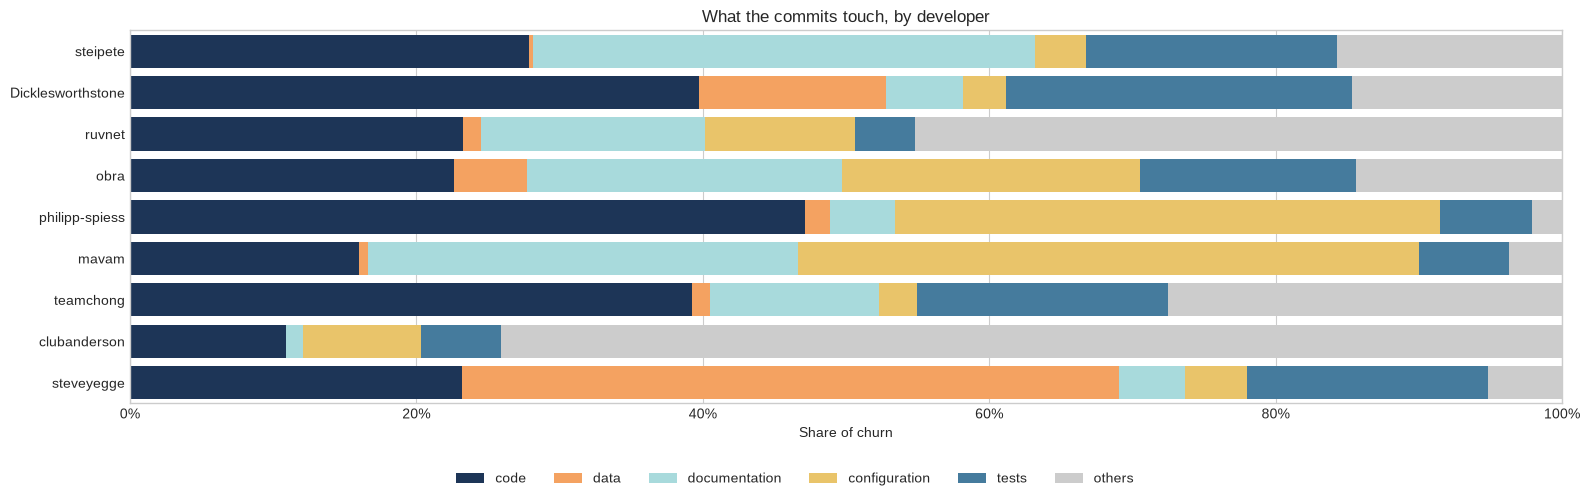

In [11]:
CATEGORY_COLORS = {
    "code": "#1d3557",
    "data": "#f4a261",
    "documentation": "#a8dadc",
    "configuration": "#e9c46a",
    "tests": "#457b9d",
    "others": "#cccccc",
}

def composition(frame: pd.DataFrame, index: str, weight: str | None = None) -> pd.DataFrame:
    """Share per category, weighted by `weight` or by the number of changed files."""
    if weight is None:
        table = frame.pivot_table(index=index, columns="category", values="filename", aggfunc="size")
    else:
        table = frame.pivot_table(index=index, columns="category", values=weight, aggfunc="sum")
    table = table.fillna(0)
    table = table.reindex(columns=CATEGORY_ORDER, fill_value=0)
    return table.div(table.sum(axis=1), axis=0)

def plot_composition(ax, table: pd.DataFrame, title: str) -> None:
    left = np.zeros(len(table))
    positions = np.arange(len(table))
    for category in CATEGORY_ORDER:
        values = table[category].to_numpy(dtype=float)
        ax.barh(positions, values, left=left, color=CATEGORY_COLORS[category], label=category)
        left += values
    ax.set_yticks(positions, table.index)
    ax.set_xlim(0, 1)
    # Set the limits rather than inverting, so the row order stays top-down.
    ax.set_ylim(len(table) - 0.5, -0.5)
    ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    ax.set_title(title)
    ax.grid(axis="y", visible=False)

developer_order = [developer for developer in developers if developer in set(file_touches["developer"])]
churn_composition = composition(file_touches, "developer", "churn").reindex(developer_order)

fig, ax = plt.subplots(figsize=(16, 5))
plot_composition(ax, churn_composition, "What the commits touch, by developer")
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6, frameon=False)
ax.set_xlabel("Share of churn")
fig.tight_layout(rect=(0, 0.08, 1, 1))
plt.show()


### Programming languages

Restricted to the files classified as source or test, extensions are mapped to languages. Extensions with no mapping are kept as `other source` rather than dropped, so the shares remain comparable across developers working in different ecosystems.


,file_changes,churn,churn_share
language,,,
Rust,"162,917","30,373,589",40.7%
TypeScript,"209,212","13,710,777",18.4%
other source,"37,157","8,617,969",11.5%
JavaScript,"15,595","4,638,264",6.2%
HTML,"2,365","3,572,062",4.8%
Go,"43,872","3,514,179",4.7%
Zig,"25,803","2,403,180",3.2%
Python,"15,317","2,357,855",3.2%
Shell,"17,766","1,943,012",2.6%


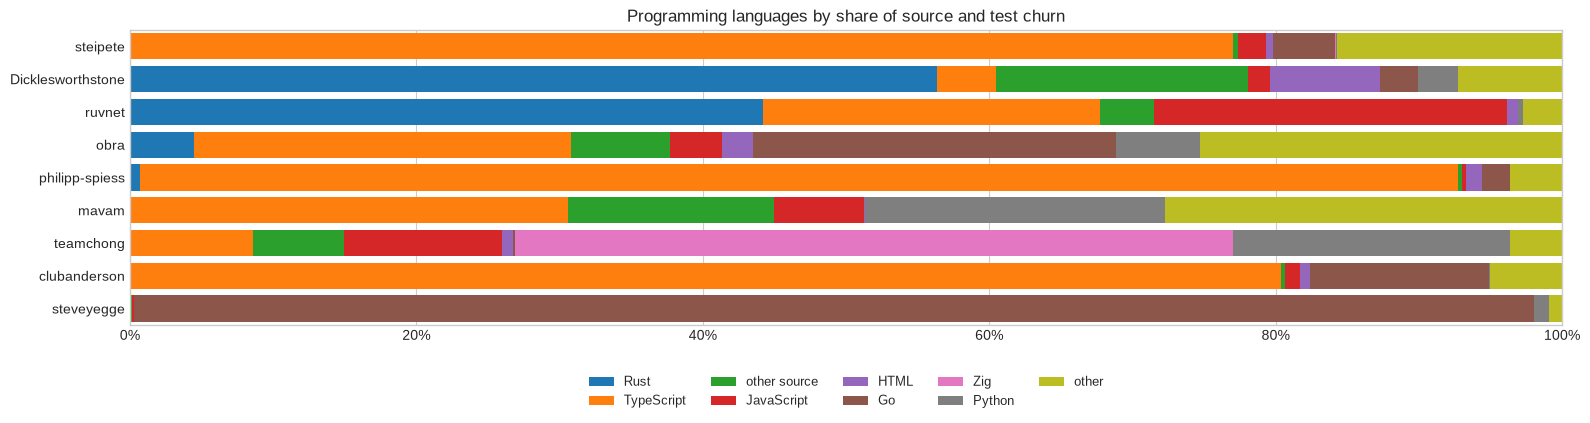

Most frequently changed extensions overall


In [12]:
LANGUAGE_NAMES = {
    "py": "Python", "ts": "TypeScript", "tsx": "TypeScript", "js": "JavaScript",
    "jsx": "JavaScript", "mjs": "JavaScript", "cjs": "JavaScript", "rs": "Rust",
    "go": "Go", "java": "Java", "kt": "Kotlin", "c": "C", "h": "C", "cc": "C++",
    "cpp": "C++", "hpp": "C++", "cs": "C#", "rb": "Ruby", "php": "PHP",
    "swift": "Swift", "scala": "Scala", "sh": "Shell", "bash": "Shell",
    "zsh": "Shell", "sql": "SQL", "lua": "Lua", "ex": "Elixir", "exs": "Elixir",
    "dart": "Dart", "vue": "Vue", "svelte": "Svelte", "zig": "Zig", "html": "HTML",
    "css": "CSS", "scss": "CSS", "m": "Objective-C", "mm": "Objective-C",
    "r": "R", "jl": "Julia", "hs": "Haskell", "clj": "Clojure", "nim": "Nim",
}

source = file_touches.loc[file_touches["category"].isin({"code", "tests"})].copy()
source["language"] = source["extension"].map(LANGUAGE_NAMES).fillna("other source")

language_totals = (
    source.groupby("language").agg(file_changes=("filename", "size"), churn=("churn", "sum"))
    .sort_values("churn", ascending=False)
)
language_totals["churn_share"] = language_totals["churn"] / language_totals["churn"].sum()
display(language_totals.head(15).style.format({
    "file_changes": "{:,.0f}", "churn": "{:,.0f}", "churn_share": "{:.1%}",
}))

top_languages = language_totals.head(8).index.tolist()
language_by_developer = (
    source.assign(language=source["language"].where(source["language"].isin(top_languages), "other"))
    .pivot_table(index="developer", columns="language", values="churn", aggfunc="sum")
    .reindex(developer_order).fillna(0)
)
language_by_developer = language_by_developer.div(language_by_developer.sum(axis=1), axis=0)
ordered_languages = top_languages + ["other"]
language_by_developer = language_by_developer.reindex(columns=ordered_languages, fill_value=0)

fig, ax = plt.subplots(figsize=(16, 4.5))
left = np.zeros(len(language_by_developer))
positions = np.arange(len(language_by_developer))
palette = plt.get_cmap("tab10")
for index, language in enumerate(ordered_languages):
    values = language_by_developer[language].to_numpy(dtype=float)
    ax.barh(positions, values, left=left, color=palette(index % 10), label=language)
    left += values
ax.set_yticks(positions, language_by_developer.index)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.set_ylim(len(language_by_developer) - 0.5, -0.5)
ax.grid(axis="y", visible=False)
ax.set_title("Programming languages by share of source and test churn")
ax.legend(ncol=5, frameon=False, fontsize=9, loc="lower center", bbox_to_anchor=(0.5, -0.32))
fig.tight_layout()
plt.show()

print("Most frequently changed extensions overall")
extension_totals = (
    file_touches.groupby(["extension", "category"]).agg(file_changes=("filename", "size"))
    .sort_values("file_changes", ascending=False).head(15)
)
display(extension_totals.style.format("{:,.0f}"))

## Coverage audit

`reported_commits` comes from each day's `total_count`; `embedded_records` is the number of actual commit objects available locally. Consequently, `unembedded_commits` cannot contribute to churn or scattering. A file count at the configured API limit is a warning that scattering and churn may be lower bounds for that commit.

In [13]:
collection_coverage = (
    snapshot_audit.groupby("developer", sort=False)
    .agg(
        snapshots=("snapshot", "count"),
        reported_commits=("reported_commits", "sum"),
        embedded_records=("embedded_records", "sum"),
        capped_days=("capped_days", "sum"),
    )
    .reindex(developers)
)
collection_coverage["unembedded_commits"] = (
    collection_coverage["reported_commits"] - collection_coverage["embedded_records"]
)

detail_coverage = (
    commits.groupby("developer", sort=False)
    .agg(
        unique_commits=("sha", "size"),
        missing_cache=("cache_present", lambda values: int((~values).sum())),
        empty_file_lists=("empty_file_list", "sum"),
        at_300_file_limit=("at_file_list_limit", "sum"),
        merge_commits=("is_merge", "sum"),
    )
    .reindex(developers)
)

coverage = collection_coverage.join(detail_coverage)
display(coverage.style.format("{:,}"))
display(coverage.sum(numeric_only=True).to_frame("all developers").T.style.format("{:,}"))

,snapshots,reported_commits,embedded_records,capped_days,unembedded_commits,unique_commits,missing_cache,empty_file_lists,at_300_file_limit,merge_commits
developer,,,,,,,,,,
steipete,6,"35,091","35,091",0,0,"35,089",0,144,48,513
Dicklesworthstone,7,"75,076","70,951",20,"4,125","70,843",0,193,79,56
ruvnet,6,"5,981","5,625",4,356,"5,383",0,18,56,283
obra,6,"4,419","4,419",0,0,"4,419",0,2,7,88
philipp-spiess,6,808,808,0,0,808,0,1,0,2
mavam,6,"2,685","2,685",0,0,"2,685",0,2,11,148
teamchong,6,"7,204","7,204",0,0,"7,204",0,5,14,0
clubanderson,6,"8,537","8,537",0,0,"8,536",0,34,8,387
steveyegge,6,"9,029","9,029",0,0,"9,029",0,44,0,"1,390"


,snapshots,reported_commits,embedded_records,capped_days,unembedded_commits,unique_commits,missing_cache,empty_file_lists,at_300_file_limit,merge_commits
all developers,55,"148,830","144,349",24,"4,481","143,996",0,443,223,"2,867"


## All developers aggregated

The first table contains additive totals over all analyzable commits. The second summarizes the per-commit distributions. Churn and file counts are strongly right-skewed, so the median and quartiles are usually more representative of a typical commit than the mean.

In [14]:
PERCENTILES = [0.05, 0.25, 0.50, 0.75, 0.95]
METRICS = ["additions", "deletions", "churn", "files_touched"]

def distribution_table(frame: pd.DataFrame) -> pd.DataFrame:
    records = []
    for metric in METRICS:
        values = frame[metric].dropna()
        quantiles = values.quantile(PERCENTILES)
        records.append({
            "metric": metric,
            "count": len(values),
            "p5": quantiles.loc[0.05],
            "p25": quantiles.loc[0.25],
            "median": quantiles.loc[0.50],
            "mean": values.mean(),
            "p75": quantiles.loc[0.75],
            "p95": quantiles.loc[0.95],
            "max": values.max(),
        })
    return pd.DataFrame(records).set_index("metric")

overall_totals = pd.DataFrame({
    "commits": [len(analysis)],
    "additions": [analysis["additions"].sum()],
    "deletions": [analysis["deletions"].sum()],
    "gross_churn": [analysis["churn"].sum()],
    "net_growth": [analysis["net_growth"].sum()],
    "file_touches": [analysis["files_touched"].sum()],
}, index=["all developers"])

display(overall_totals.style.format("{:,}"))
display(distribution_table(analysis).style.format({
    "count": "{:,.0f}",
    "p5": "{:,.1f}", "p25": "{:,.1f}", "median": "{:,.1f}",
    "mean": "{:,.1f}", "p75": "{:,.1f}", "p95": "{:,.1f}", "max": "{:,.0f}",
}))

,commits,additions,deletions,gross_churn,net_growth,file_touches
all developers,"143,996","117,808,344","42,915,522","160,723,866","74,892,822","1,025,505"


,count,p5,p25,median,mean,p75,p95,max
metric,,,,,,,,
additions,"143,996",1.0,7.0,49.0,818.1,207.2,"1,274.0","6,855,492"
deletions,"143,996",0.0,1.0,5.0,298.0,25.0,245.2,"5,418,272"
churn,"143,996",2.0,13.0,70.0,"1,116.2",263.0,"1,610.0","6,855,492"
files_touched,"143,996",1.0,1.0,2.0,7.1,4.0,14.0,"20,241"


## Results by developer

In [15]:
developer_totals = (
    analysis.groupby("developer", sort=False)
    .agg(
        commits=("sha", "size"),
        additions=("additions", "sum"),
        deletions=("deletions", "sum"),
        gross_churn=("churn", "sum"),
        net_growth=("net_growth", "sum"),
        file_touches=("files_touched", "sum"),
    )
    .reindex(developers)
)
display(developer_totals.style.format("{:,}"))

,commits,additions,deletions,gross_churn,net_growth,file_touches
developer,,,,,,
steipete,"35,089","10,100,591","7,231,220","17,331,811","2,869,371","267,307"
Dicklesworthstone,"70,843","56,889,443","11,413,969","68,303,412","45,475,474","401,553"
ruvnet,"5,383","33,151,194","14,401,078","47,552,272","18,750,116","148,263"
obra,"4,419","1,582,836","491,237","2,074,073","1,091,599","22,189"
philipp-spiess,808,"168,031","57,968","225,999","110,063","2,943"
mavam,"2,685","778,875","947,416","1,726,291","-168,541","27,807"
teamchong,"7,204","6,439,442","1,995,835","8,435,277","4,443,607","46,482"
clubanderson,"8,536","6,426,355","4,667,967","11,094,322","1,758,388","78,906"
steveyegge,"9,029","2,271,577","1,708,832","3,980,409","562,745","30,055"


In [16]:
def metric_by_developer(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    grouped = frame.groupby("developer", sort=False)[metric]
    result = grouped.agg(count="size", minimum="min", mean="mean", maximum="max")
    quantiles = grouped.quantile(PERCENTILES).unstack()
    quantiles.columns = ["p5", "p25", "median", "p75", "p95"]
    return (
        result[["count", "minimum"]]
        .join(quantiles[["p5", "p25", "median"]])
        .join(result[["mean"]])
        .join(quantiles[["p75", "p95"]])
        .join(result[["maximum"]])
        .reindex(developers)
    )

print("Per-commit additions")
display(metric_by_developer(analysis, "additions").style.format("{:,.1f}"))
print("Per-commit deletions")
display(metric_by_developer(analysis, "deletions").style.format("{:,.1f}"))
print("Per-commit gross churn (additions + deletions)")
display(metric_by_developer(analysis, "churn").style.format("{:,.1f}"))
print("Per-commit file scattering (files touched)")
display(metric_by_developer(analysis, "files_touched").style.format("{:,.1f}"))

Per-commit additions


,count,minimum,p5,p25,median,mean,p75,p95,maximum
developer,,,,,,,,,
steipete,"35,089.0",0.0,1.0,6.0,32.0,287.9,113.0,586.0,"2,348,356.0"
Dicklesworthstone,"70,843.0",0.0,1.0,9.0,68.0,803.0,300.0,"1,536.0","6,855,492.0"
ruvnet,"5,383.0",0.0,1.0,4.0,32.0,"6,158.5",410.5,"12,114.0","3,526,891.0"
obra,"4,419.0",0.0,1.0,16.0,64.0,358.2,191.0,846.1,"141,344.0"
philipp-spiess,808.0,0.0,0.4,2.0,15.0,208.0,105.2,953.6,"18,389.0"
mavam,"2,685.0",0.0,0.0,5.0,22.0,290.1,90.0,708.2,"229,967.0"
teamchong,"7,204.0",0.0,1.0,11.0,52.0,893.9,227.0,"1,798.8","462,182.0"
clubanderson,"8,536.0",0.0,1.0,10.0,46.0,752.9,109.0,857.2,"3,925,715.0"
steveyegge,"9,029.0",0.0,1.0,6.0,40.0,251.6,180.0,833.6,"50,182.0"


Per-commit deletions


,count,minimum,p5,p25,median,mean,p75,p95,maximum
developer,,,,,,,,,
steipete,"35,089.0",0.0,0.0,1.0,7.0,206.1,37.0,291.0,"2,364,214.0"
Dicklesworthstone,"70,843.0",0.0,0.0,1.0,4.0,161.1,20.0,182.0,"1,695,122.0"
ruvnet,"5,383.0",0.0,0.0,0.0,2.0,"2,675.3",17.0,411.5,"5,418,272.0"
obra,"4,419.0",0.0,0.0,0.0,3.0,111.2,15.0,125.0,"141,344.0"
philipp-spiess,808.0,0.0,0.0,1.0,4.0,71.7,24.0,209.3,"22,110.0"
mavam,"2,685.0",0.0,0.0,1.0,6.0,352.9,33.0,324.8,"613,245.0"
teamchong,"7,204.0",0.0,0.0,2.0,10.0,277.0,40.0,425.8,"158,269.0"
clubanderson,"8,536.0",0.0,0.0,0.0,4.0,546.9,18.0,157.0,"3,914,668.0"
steveyegge,"9,029.0",0.0,0.0,1.0,5.0,189.3,30.0,757.2,"66,832.0"


Per-commit gross churn (additions + deletions)


,count,minimum,p5,p25,median,mean,p75,p95,maximum
developer,,,,,,,,,
steipete,"35,089.0",0.0,2.0,11.0,50.0,493.9,165.0,899.0,"2,382,134.0"
Dicklesworthstone,"70,843.0",0.0,2.0,14.0,88.0,964.2,346.0,"1,771.9","6,855,492.0"
ruvnet,"5,383.0",0.0,2.0,6.0,46.0,"8,833.8",501.5,"13,768.8","5,418,284.0"
obra,"4,419.0",0.0,3.0,23.0,81.0,469.4,219.0,982.2,"141,424.0"
philipp-spiess,808.0,0.0,2.0,5.0,27.0,279.7,159.2,"1,312.8","23,037.0"
mavam,"2,685.0",0.0,2.0,10.0,36.0,642.9,147.0,"1,128.6","613,247.0"
teamchong,"7,204.0",0.0,3.0,21.0,82.0,"1,170.9",313.0,"2,388.0","462,470.0"
clubanderson,"8,536.0",0.0,2.0,16.0,68.0,"1,299.7",147.0,"1,123.0","3,925,715.0"
steveyegge,"9,029.0",0.0,2.0,11.0,63.0,440.8,244.0,"1,608.6","66,836.0"


Per-commit file scattering (files touched)


,count,minimum,p5,p25,median,mean,p75,p95,maximum
developer,,,,,,,,,
steipete,"35,089.0",0.0,1.0,1.0,2.0,7.6,5.0,17.0,"20,241.0"
Dicklesworthstone,"70,843.0",0.0,1.0,1.0,2.0,5.7,3.0,12.0,"17,647.0"
ruvnet,"5,383.0",0.0,1.0,1.0,1.0,27.5,5.0,55.0,"9,675.0"
obra,"4,419.0",0.0,1.0,1.0,2.0,5.0,4.0,11.0,871.0
philipp-spiess,808.0,0.0,1.0,1.0,2.0,3.6,3.0,12.0,132.0
mavam,"2,685.0",0.0,1.0,1.0,2.0,10.4,4.0,20.0,"2,732.0"
teamchong,"7,204.0",0.0,1.0,1.0,2.0,6.5,5.0,16.0,"1,469.0"
clubanderson,"8,536.0",0.0,1.0,1.0,2.0,9.2,4.0,14.0,"19,664.0"
steveyegge,"9,029.0",0.0,1.0,1.0,2.0,3.3,3.0,10.0,259.0


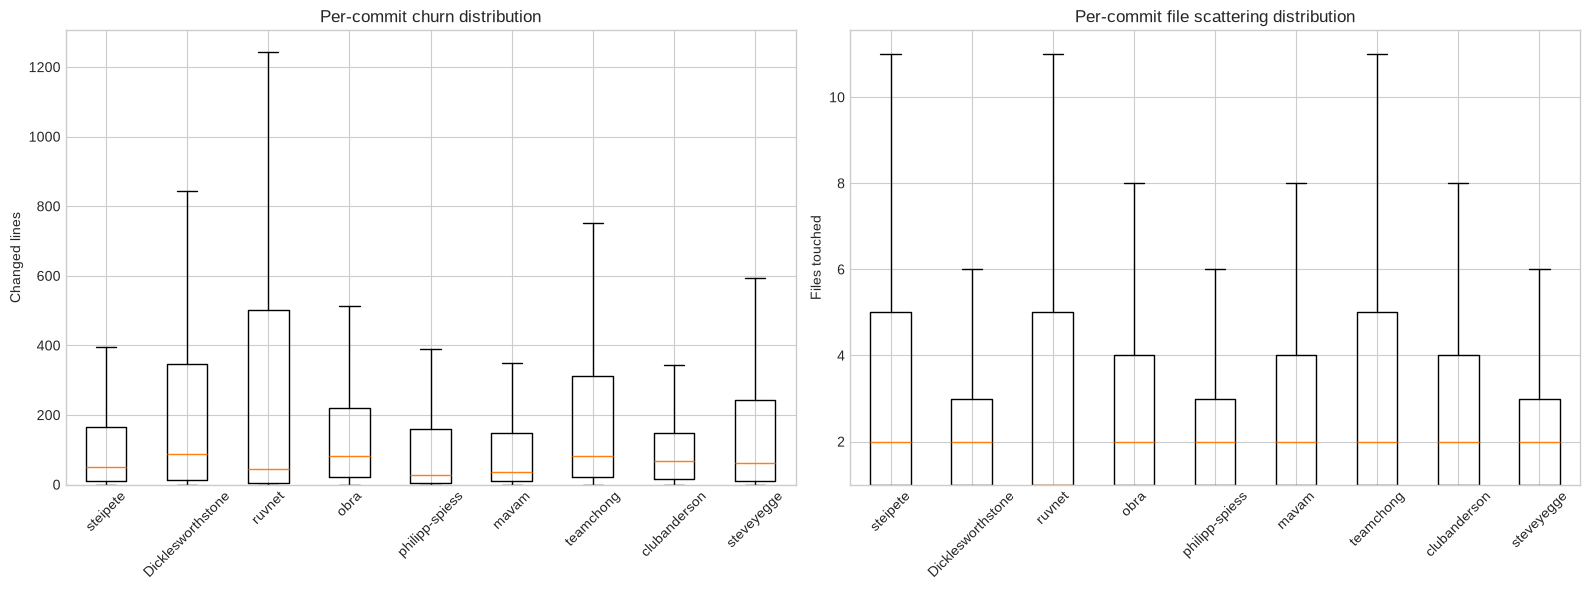

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

churn_series = [analysis.loc[analysis.developer == dev, "churn"] for dev in developers]
file_series = [analysis.loc[analysis.developer == dev, "files_touched"] for dev in developers]

axes[0].boxplot(churn_series, tick_labels=developers, showfliers=False)
axes[0].set_title("Per-commit churn distribution")
axes[0].set_ylabel("Changed lines")
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis="x", rotation=45)

axes[1].boxplot(file_series, tick_labels=developers, showfliers=False)
axes[1].set_title("Per-commit file scattering distribution")
axes[1].set_ylabel("Files touched")
axes[1].set_ylim(bottom=1)
axes[1].tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()

## Daily evolution of churn and scattering

These plots summarize the distribution of **per-commit** churn and file scattering on each UTC observation day. The solid line is the daily median, the dashed line is the daily mean, and the shaded band spans p25–p75. Days without analyzable commits remain gaps rather than being interpreted as zero-churn days.

The combined-cohort view pools all commits made by all developers on each day, so it is intentionally weighted by developer commit volume. The small multiples apply the same calculation independently to each developer.

In [18]:
OBSERVATION_DAYS = pd.date_range(START_DATE, END_DATE, freq="D")
OBSERVATION_MONTHS = pd.period_range(START_DATE, END_DATE, freq="M").astype(str)

def daily_metric_summary(
    frame: pd.DataFrame, metric: str, developer: str | None = None
) -> pd.DataFrame:
    selected = frame if developer is None else frame.loc[frame["developer"] == developer]
    grouped = selected.groupby("day")[metric]
    daily = grouped.agg(mean="mean", median="median")
    daily["p25"] = grouped.quantile(0.25)
    daily["p75"] = grouped.quantile(0.75)
    return daily.reindex(OBSERVATION_DAYS).rename_axis("day")

def monthly_metric_summary(
    frame: pd.DataFrame, metric: str, developer: str
) -> pd.DataFrame:
    """Monthly commit count and per-commit median, without aggregating daily medians."""
    selected = frame.loc[frame["developer"] == developer]
    monthly = selected.groupby("month")[metric].agg(commits="size", median="median")
    return monthly.reindex(OBSERVATION_MONTHS).rename_axis("month")

def plot_monthly_medians(metric: str, ylabel: str) -> None:
    """Show the heterogeneous monthly trajectories on one complete shared scale."""
    fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharex=True, sharey=True)
    positions = np.arange(len(OBSERVATION_MONTHS))
    for ax, developer in zip(axes.flat, developers):
        monthly = monthly_metric_summary(analysis, metric, developer)
        ax.plot(positions, monthly["median"], marker="o", color="#1d3557")
        ax.set_title(developer)
        ax.set_xticks(positions, [month[5:] for month in OBSERVATION_MONTHS])
        ax.set_ylim(bottom=0)
    for ax in axes[:, 0]:
        ax.set_ylabel(ylabel)
    for ax in axes[-1, :]:
        ax.set_xlabel("Month (2025-11 to 2026-04)")
    fig.suptitle(f"Monthly median {ylabel.lower()} by developer")
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()

def plot_daily_evolution(
    ax: plt.Axes, daily: pd.DataFrame, title: str, ylabel: str, numeric_minimum: int = 0
) -> None:
    dates = daily.index.to_numpy()
    ax.fill_between(
        dates,
        daily["p25"].to_numpy(dtype=float),
        daily["p75"].to_numpy(dtype=float),
        color="#457b9d",
        alpha=0.20,
        label="p25–p75",
    )
    ax.plot(dates, daily["median"], color="#1d3557", linewidth=1.5, label="median")
    ax.plot(dates, daily["mean"], color="#e76f51", linewidth=1.1, linestyle="--", label="mean")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlim(START_DATE, END_DATE)
    ax.set_ylim(bottom=numeric_minimum)
    ax.tick_params(axis="x", rotation=30)

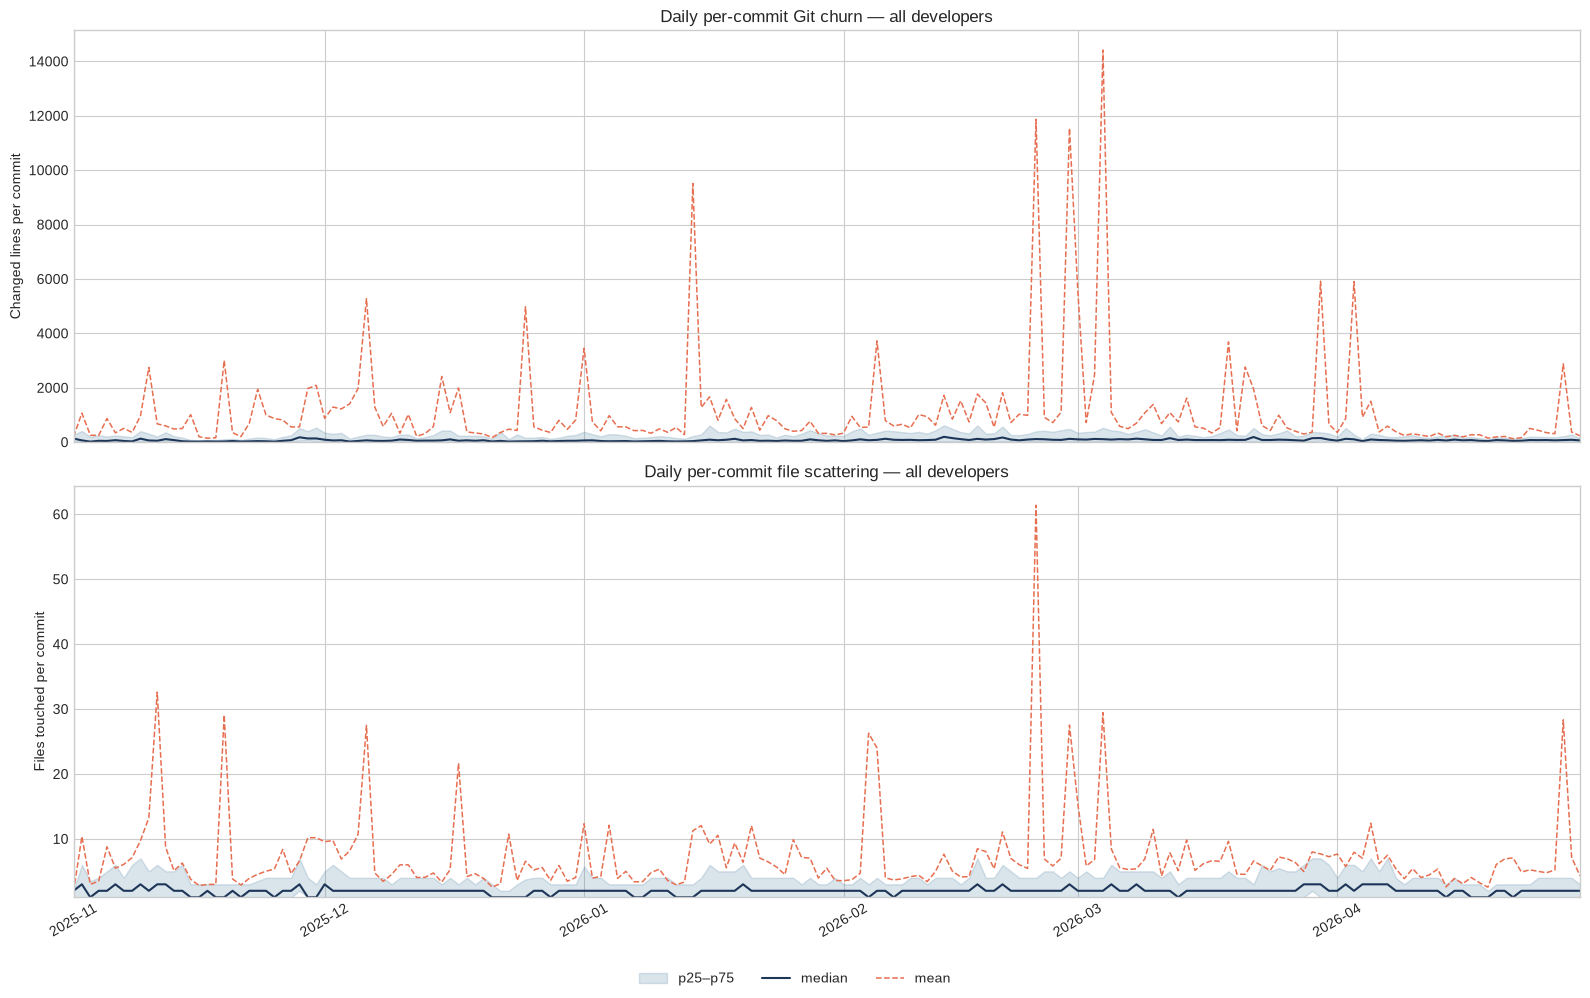

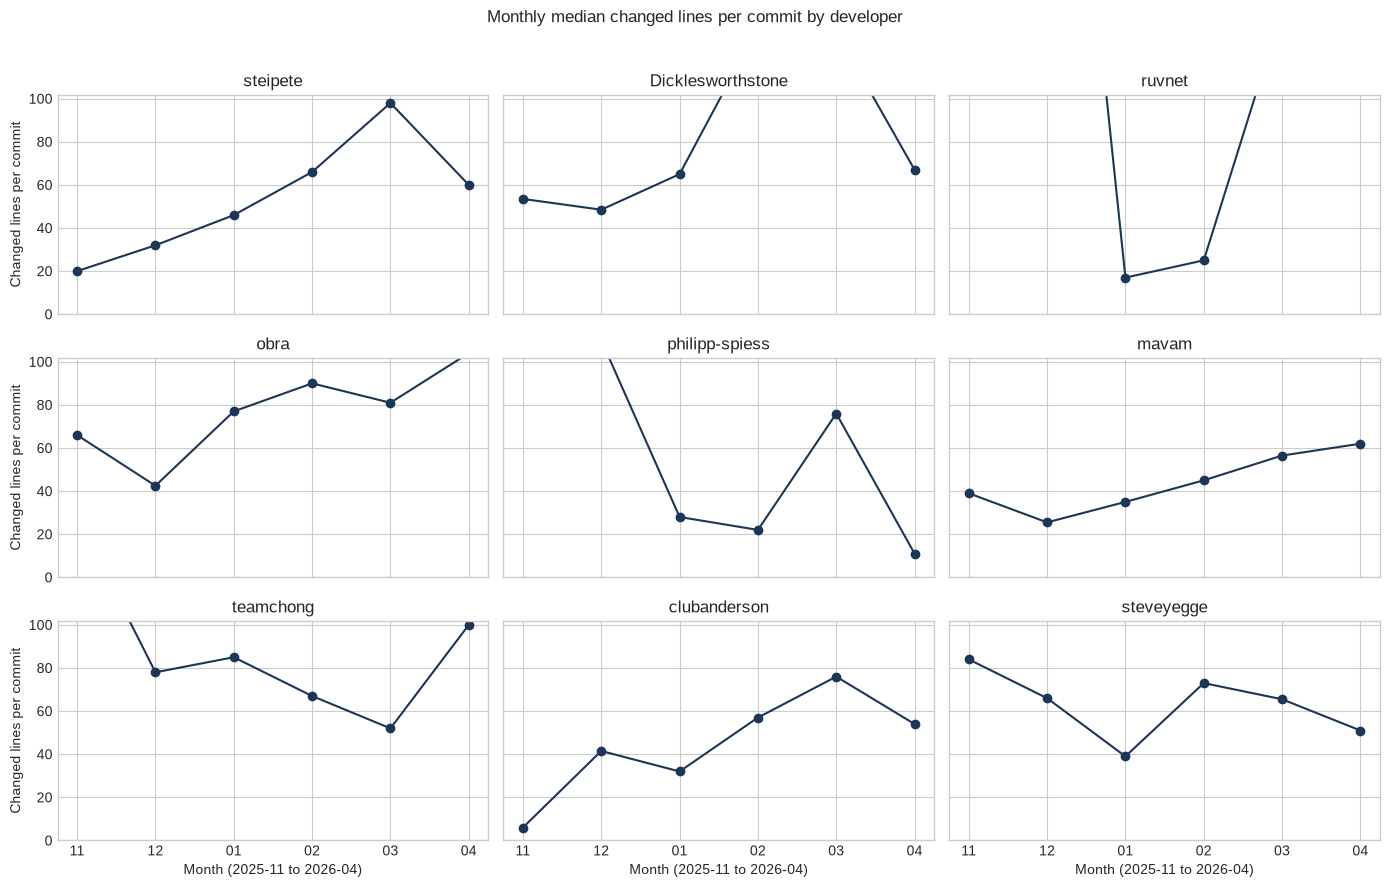

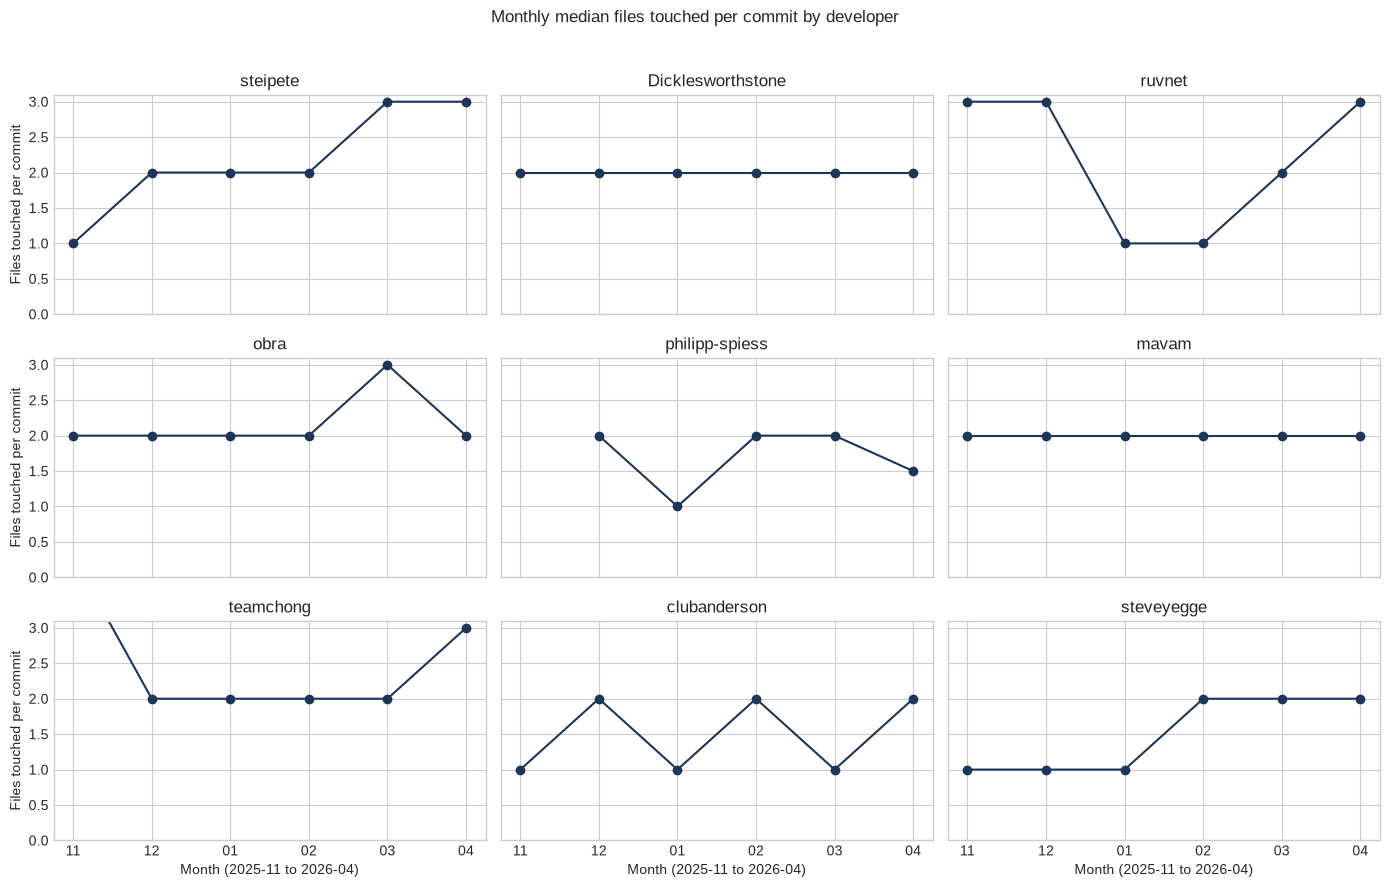

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

plot_daily_evolution(
    axes[0],
    daily_metric_summary(analysis, "churn"),
    "Daily per-commit Git churn — all developers",
    "Changed lines per commit",
)
plot_daily_evolution(
    axes[1],
    daily_metric_summary(analysis, "files_touched"),
    "Daily per-commit file scattering — all developers",
    "Files touched per commit",
    numeric_minimum=1,
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

plot_monthly_medians("churn", "Changed lines per commit")
plot_monthly_medians("files_touched", "Files touched per commit")

## Merge-commit sensitivity check

A merge diff may repeat changes already represented by its constituent commits. The table below applies the merge policy to the same Git-preferred dataset as the headline results and reports totals with and without merge commits.

In [20]:
def sensitivity_totals(frame: pd.DataFrame, label: str) -> dict:
    return {
        "policy": label,
        "commits": len(frame),
        "additions": frame["additions"].sum(),
        "deletions": frame["deletions"].sum(),
        "gross_churn": frame["churn"].sum(),
        "file_touches": frame["files_touched"].sum(),
    }

sensitivity = pd.DataFrame([
    sensitivity_totals(analysis, "including merges"),
    sensitivity_totals(analysis.loc[~analysis["is_merge"]], "excluding merges"),
]).set_index("policy")
display(sensitivity.style.format("{:,}"))

,commits,additions,deletions,gross_churn,file_touches
policy,,,,,
including merges,"143,996","117,808,344","42,915,522","160,723,866","1,025,505"
excluding merges,"141,129","101,476,938","36,055,785","137,532,723","930,196"


## Interpretation caveats

1. Statistics cover all **embedded commit records**, not unsampled commits represented only by a daily `total_count`. Exact churn cannot be inferred without their SHAs and diffs.
2. A cache entry with no files may represent a genuine empty commit or an unavailable/deleted repository; it is retained as zero but counted in the audit.
3. The collector did not paginate commit details. Cached commits containing exactly 300 files may therefore have truncated file lists, making their churn and scattering lower bounds. GitHub's REST endpoint can be paginated to 3,000 files; 300 is not the absolute API limit.
4. Raw churn includes generated files, lockfiles, vendored code, and data. Filtering those categories would answer a different question and should be reported as a separate sensitivity analysis.
5. Means are especially sensitive to very large commits. Prefer medians and interquartile ranges when describing a typical commit.

## Alternative readable aggregate and developer comparisons

The following visualizations supplement the preceding plots without replacing them. The aggregate views focus on the median and interquartile band so that extreme commits do not hide the typical commit. Churn axes start at zero; file-touch axes start at one.

For individual comparisons, eight developers use exactly the same **2025-11-01 to 2026-04-30 time axis**, tick positions, and numeric Y range. `ruvnet` appears in a separate full-width panel with the same dates but an independent Y range because its churn and scattering are on a substantially different scale.

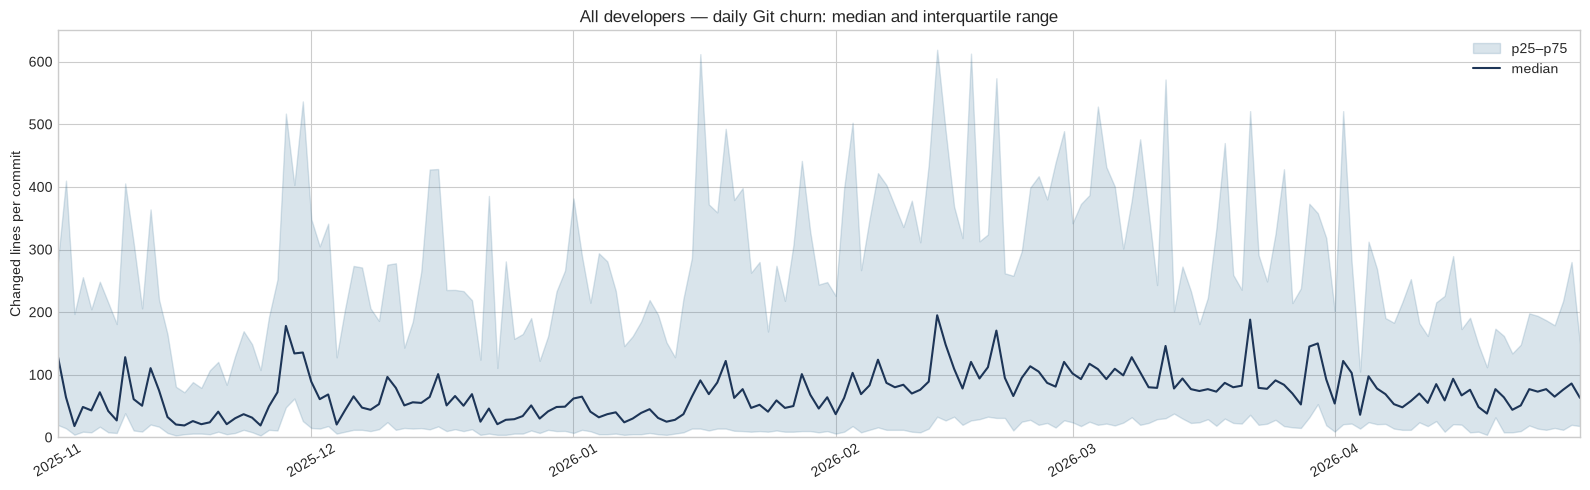

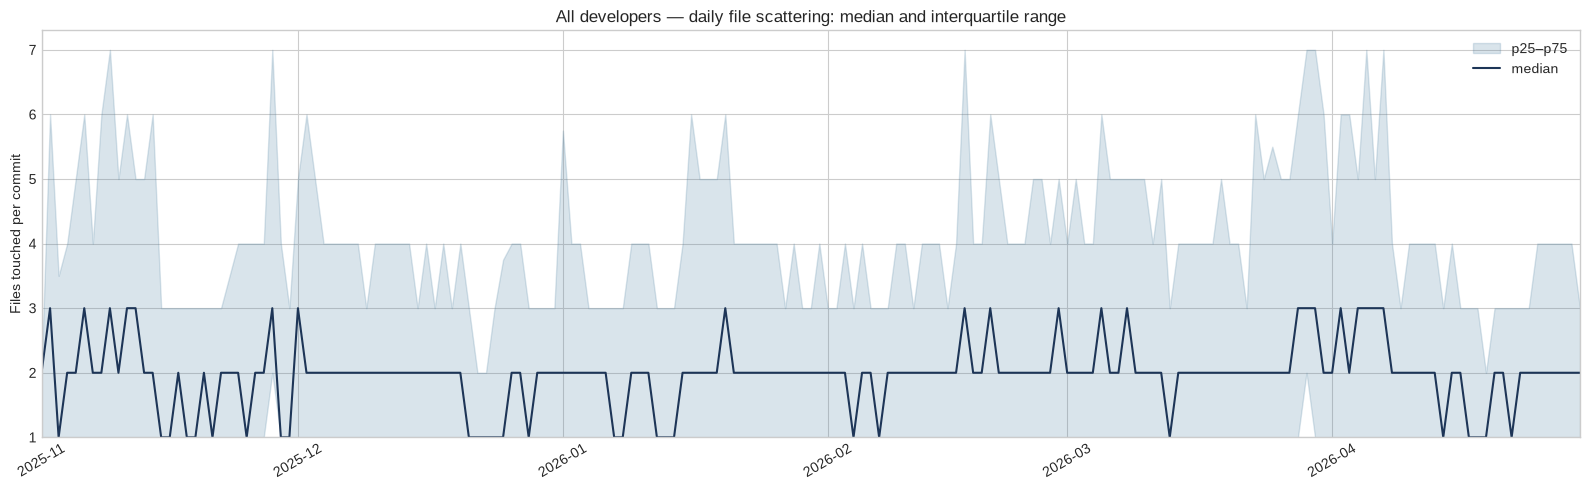

In [21]:
from matplotlib import dates as mdates

def plot_aggregate_metric_central(metric: str, ylabel: str, heading: str) -> None:
    daily = daily_metric_summary(analysis, metric)
    dates = daily.index.to_numpy()
    fig, ax = plt.subplots(figsize=(16, 5))

    ax.fill_between(
        dates, daily["p25"].to_numpy(dtype=float), daily["p75"].to_numpy(dtype=float),
        color="#457b9d", alpha=0.20, label="p25–p75",
    )
    ax.plot(dates, daily["median"], color="#1d3557", linewidth=1.5, label="median")
    ax.set_title(f"{heading}: median and interquartile range")
    ax.set_ylabel(ylabel)
    ax.set_xlim(START_DATE, END_DATE)
    ax.set_ylim(bottom=1 if metric == "files_touched" else 0)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(axis="x", rotation=30)
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

plot_aggregate_metric_central("churn", "Changed lines per commit", "All developers — daily Git churn")
plot_aggregate_metric_central("files_touched", "Files touched per commit", "All developers — daily file scattering")

## Per-developer evolution of churn and scattering

The aggregate views above pool the whole cohort, which hides who drives a given movement. The two figures below apply exactly the same daily calculation to each developer, one row per developer: churn first, file scattering second. As above, the solid line is the daily median, the dashed line is the daily mean, and the shaded band spans p25–p75. Days without analyzable commits stay gaps.

The eight comparable developers share the same time axis, tick positions, and Y range within a figure, so their rows can be read against one another directly. That shared Y range covers the bulk of the daily statistics rather than their extremes, because a single day carrying one very large commit would otherwise flatten every other panel; each panel reports how many days run past the top of its axis. `ruvnet` is an order of magnitude larger on both metrics, so its row keeps an independent Y range and is outlined in red — its curves must not be compared by eye to the rows above.


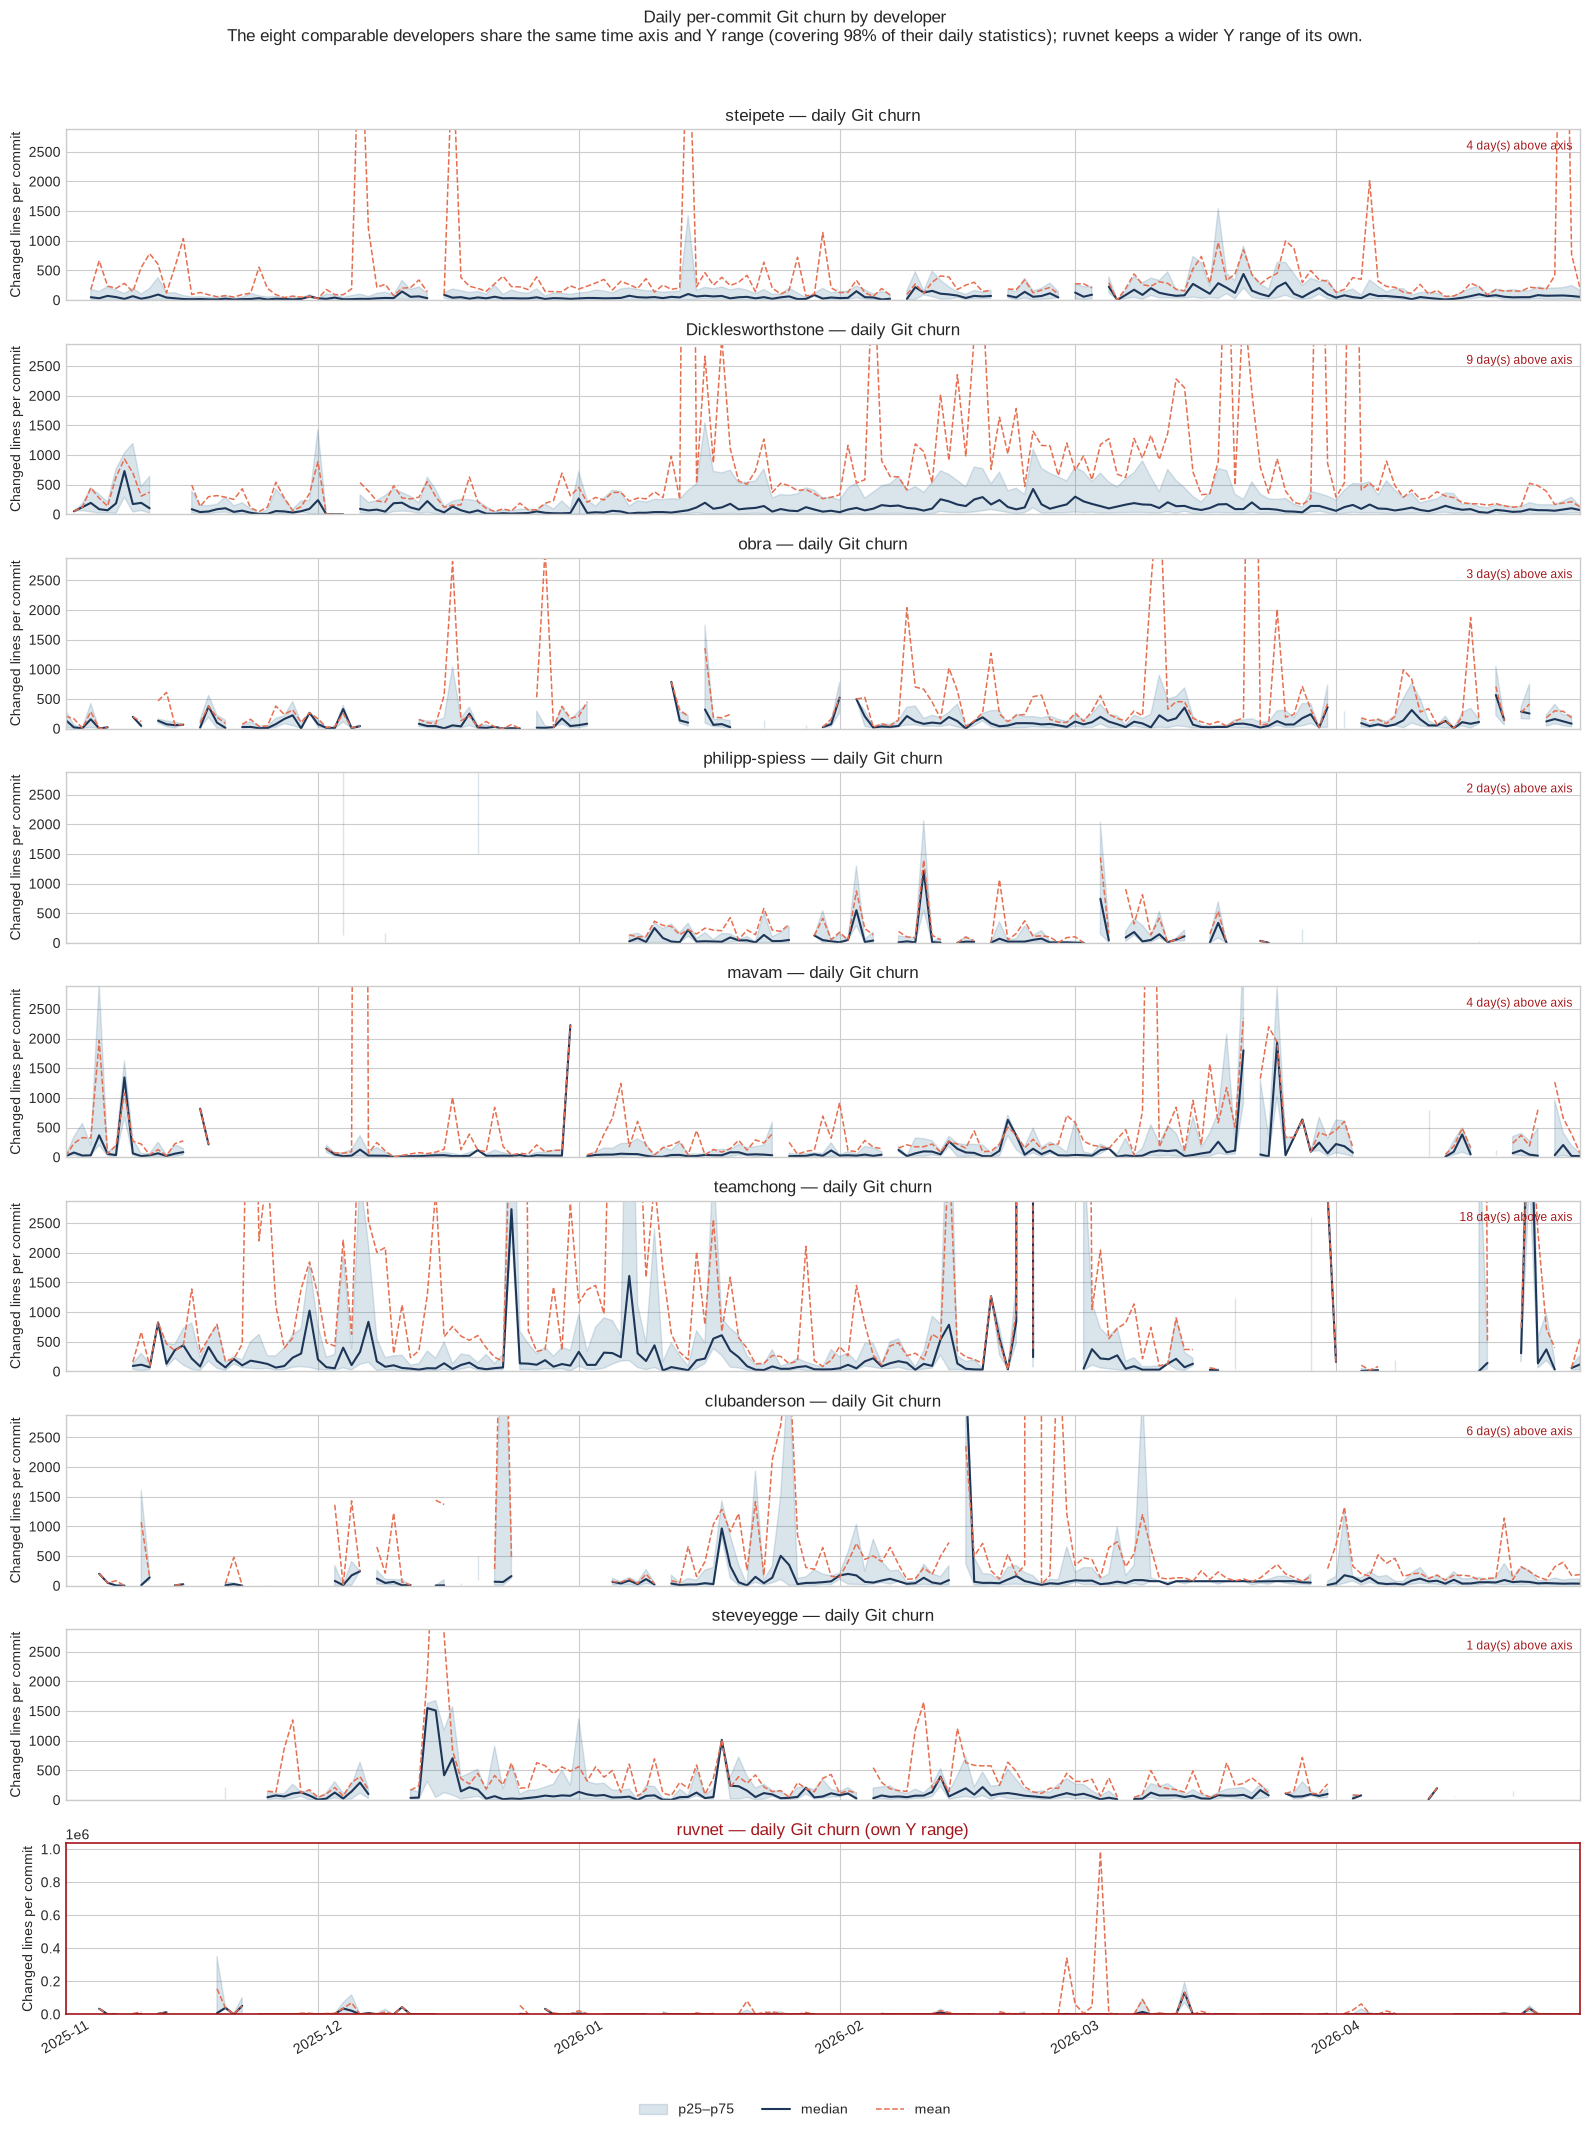

In [22]:
OUTLIER_DEVELOPER = "ruvnet"
SHARED_DEVELOPERS = [developer for developer in developers if developer != OUTLIER_DEVELOPER]
PANEL_ORDER = SHARED_DEVELOPERS + [OUTLIER_DEVELOPER]

# A single day dominated by one very large commit would otherwise flatten every
# other panel, so the shared Y range covers the bulk of the daily statistics and
# each panel reports how many days run off the top of its axis.
SHARED_COVERAGE = 0.98
PLOTTED_STATISTICS = ["mean", "median", "p75"]

def upper_limit(frames: list[pd.DataFrame], coverage: float) -> float:
    plotted = pd.concat([frame[PLOTTED_STATISTICS].stack() for frame in frames])
    return float(plotted.quantile(coverage)) * 1.05

def plot_developer_small_multiples(
    metric: str, ylabel: str, heading: str, numeric_minimum: int = 0
) -> None:
    daily_by_developer = {
        developer: daily_metric_summary(analysis, metric, developer)
        for developer in PANEL_ORDER
    }
    shared_upper = upper_limit(
        [daily_by_developer[developer] for developer in SHARED_DEVELOPERS], SHARED_COVERAGE
    )
    outlier_upper = upper_limit([daily_by_developer[OUTLIER_DEVELOPER]], 1.0)

    fig, axes = plt.subplots(
        len(PANEL_ORDER), 1, figsize=(16, 2.4 * len(PANEL_ORDER)), sharex=True
    )

    for ax, developer in zip(axes, PANEL_ORDER):
        is_outlier = developer == OUTLIER_DEVELOPER
        daily = daily_by_developer[developer]
        upper = outlier_upper if is_outlier else shared_upper
        plot_daily_evolution(
            ax,
            daily,
            f"{developer} — daily {heading}" + (" (own Y range)" if is_outlier else ""),
            ylabel,
            numeric_minimum=numeric_minimum,
        )
        ax.set_ylim(numeric_minimum, upper)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

        above_axis = int((daily[PLOTTED_STATISTICS] > upper).any(axis=1).sum())
        if above_axis:
            ax.text(
                0.995, 0.90, f"{above_axis} day(s) above axis",
                transform=ax.transAxes, ha="right", va="center", fontsize=8.5,
                color="#a4161a",
            )
        if is_outlier:
            ax.title.set_color("#a4161a")
            for spine in ax.spines.values():
                spine.set_edgecolor("#a4161a")
                spine.set_linewidth(1.2)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
    fig.suptitle(
        f"Daily per-commit {heading} by developer\n"
        f"The eight comparable developers share the same time axis and Y range "
        f"(covering {SHARED_COVERAGE:.0%} of their daily statistics); "
        f"{OUTLIER_DEVELOPER} keeps a wider Y range of its own.",
        fontsize=12,
    )
    fig.tight_layout(rect=(0, 0.025, 1, 0.965))
    plt.show()

plot_developer_small_multiples("churn", "Changed lines per commit", "Git churn")

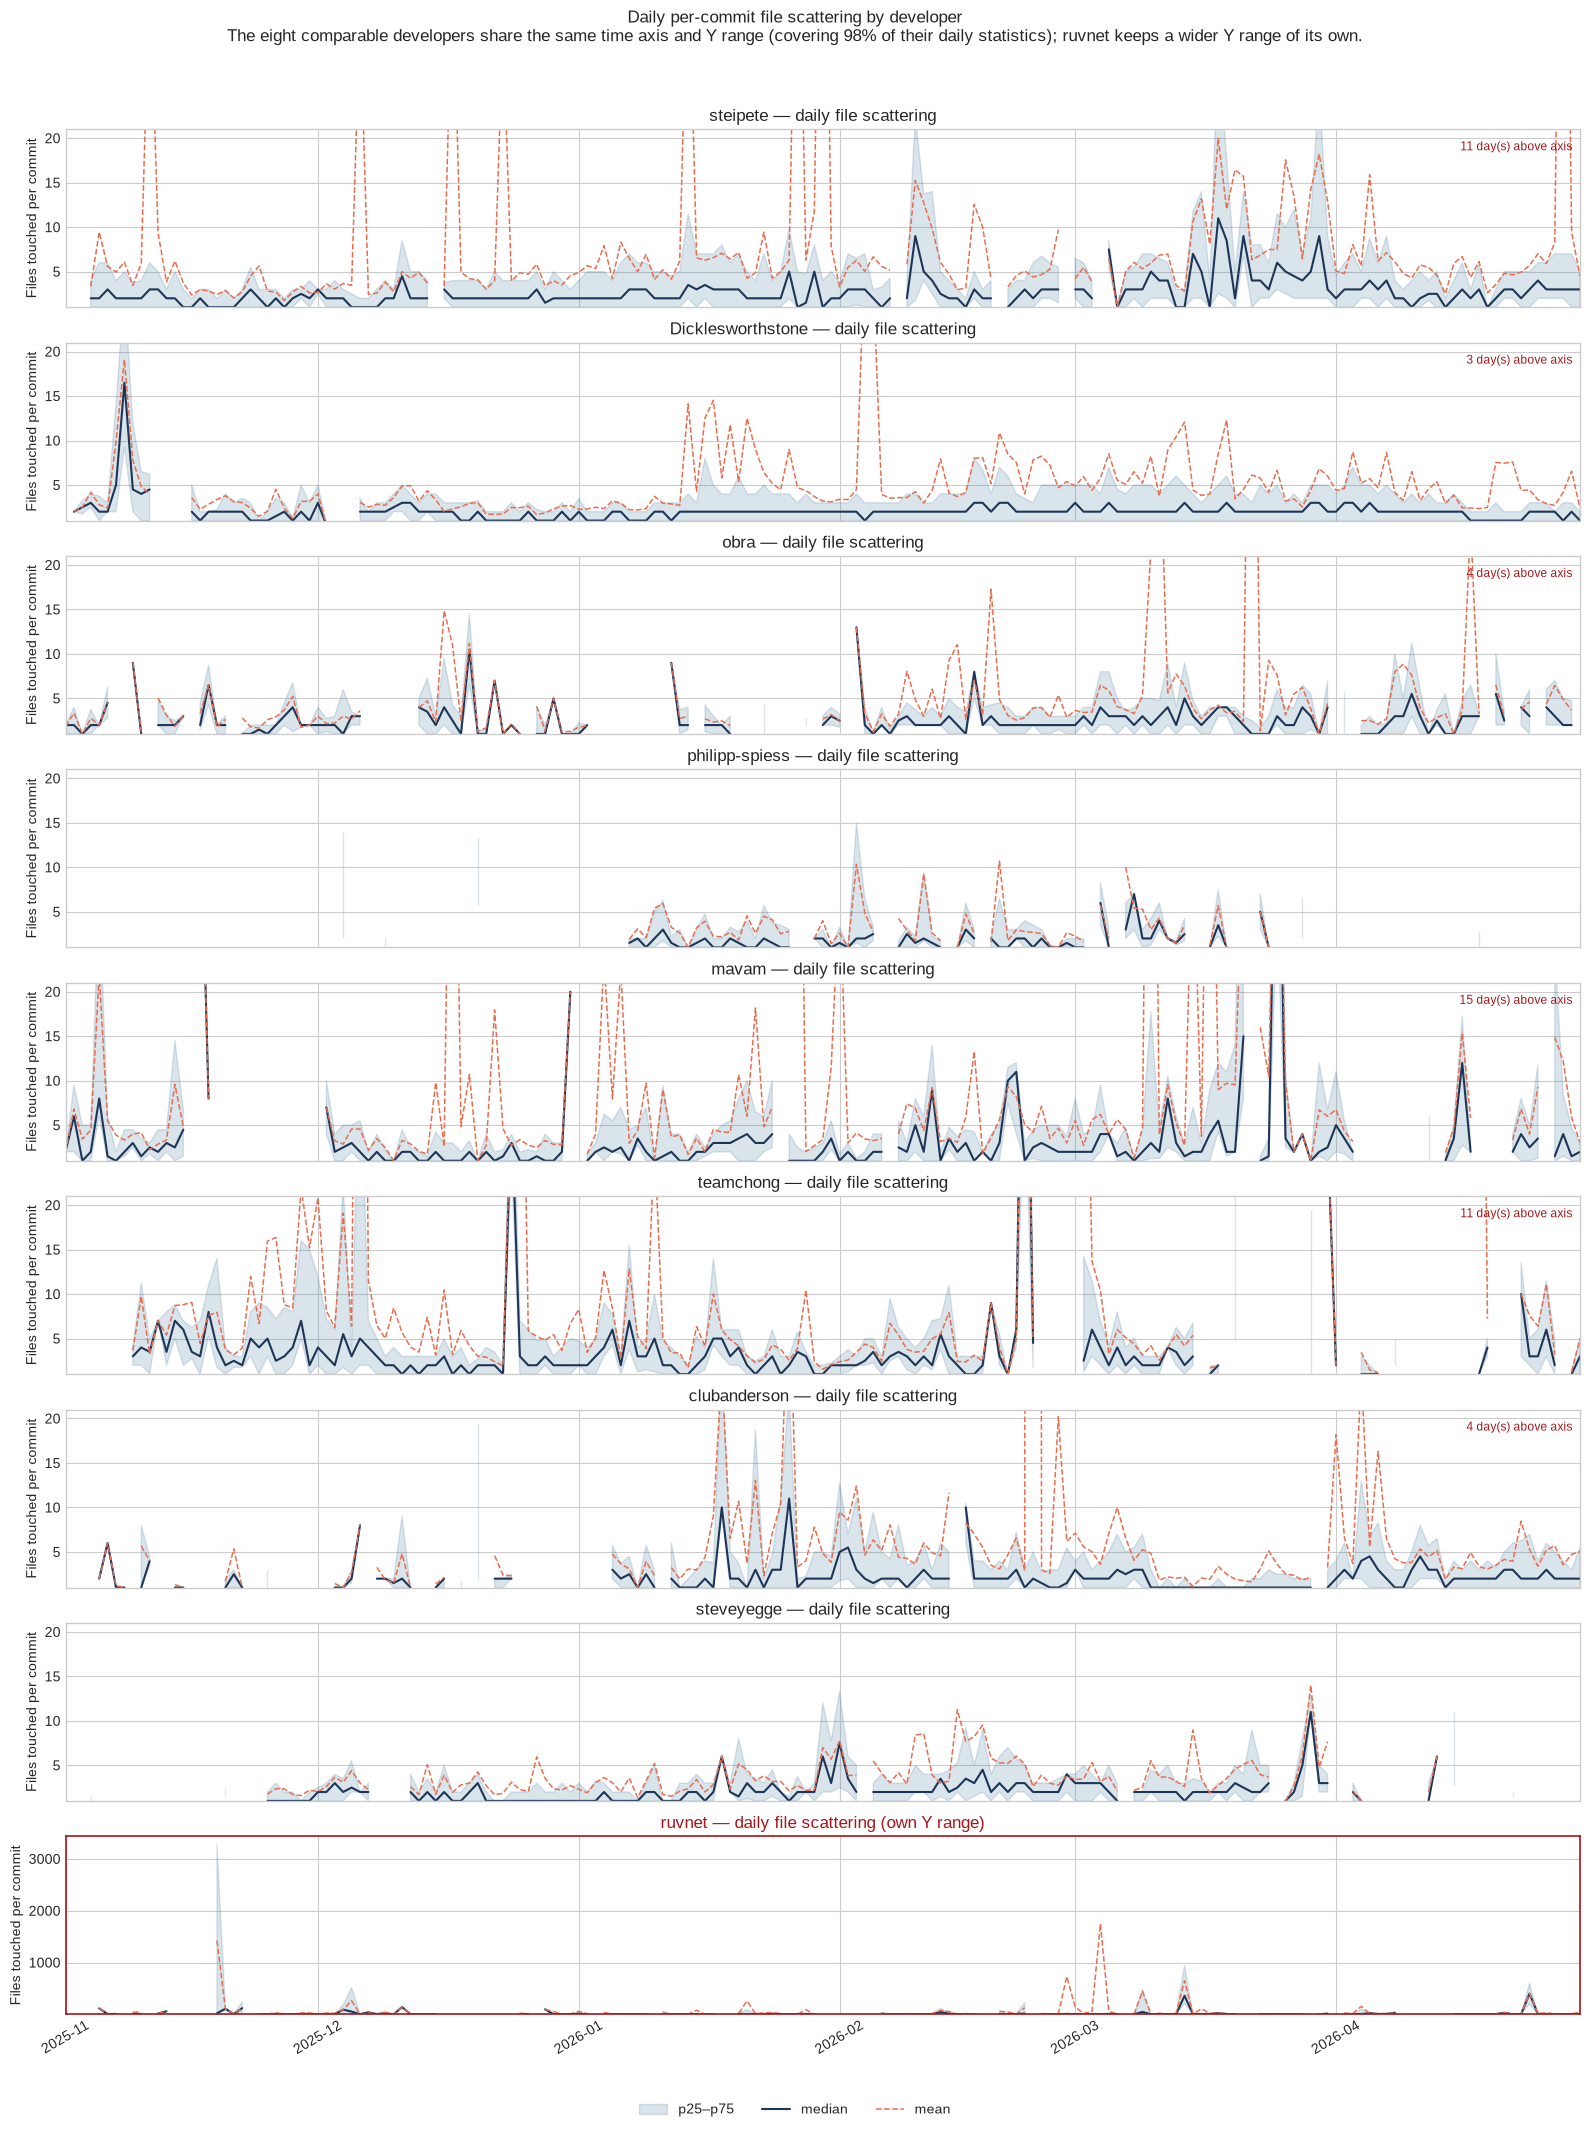

In [23]:
plot_developer_small_multiples(
    "files_touched", "Files touched per commit", "file scattering", numeric_minimum=1
)

## Commit breadth, daily volume, and file revisits

Churn and file scattering describe how much a commit changes. Two further measures describe how that change is placed. *Breadth* counts the distinct top-level directories, or modules, a commit spans, and is reported alongside the daily volume in which commits are produced, including whether a busier day is made of smaller commits (`rho_commits_median_churn`) or simply of more of them (`rho_commits_daily_churn`).

A *revisit* is a change to a file the same developer already changed earlier in the window, in the same repository. High revisit rates indicate that output concentrates on recently written code. Agent state files, such as in-repository issue trackers and agent memory, are rewritten by tooling on nearly every commit, so their share is reported next to the revisit rates they inflate.


In [24]:
PAPER_FIGURE_DIR = ROOT / "paper" / "figures" / "rq4"
EXPORT_DIR = DATA_DIR / "rq4"

def breadth_table() -> pd.DataFrame:
    daily = analysis.groupby(["developer", "day"]).agg(
        commits=("sha", "size"), churn=("churn", "sum")
    )
    grouped = analysis.groupby("developer")
    table = pd.DataFrame({
        "commits": grouped["sha"].size(),
        "median_files": grouped["files_touched"].median(),
        "p95_files": grouped["files_touched"].quantile(0.95),
        "median_modules": grouped["modules"].median(),
        "mean_modules": grouped["modules"].mean(),
        "multi_module_share": grouped["modules"].apply(lambda values: (values > 1).mean()),
        "focused_share": grouped["files_touched"].apply(lambda values: (values <= 5).mean()),
        "scattered_share": grouped["files_touched"].apply(lambda values: (values > 10).mean()),
        "active_days": daily.groupby("developer")["commits"].size(),
        "median_commits_per_day": daily.groupby("developer")["commits"].median(),
        "median_daily_churn": daily.groupby("developer")["churn"].median(),
        "p95_daily_churn": daily.groupby("developer")["churn"].quantile(0.95),
    })
    # Does a busier day consist of smaller commits, or simply of more of them?
    per_day = analysis.groupby(["developer", "day"]).agg(
        commits=("sha", "size"), median_churn=("churn", "median"), churn=("churn", "sum")
    )
    table["rho_commits_median_churn"] = per_day.groupby("developer").apply(
        lambda frame: frame["commits"].rank().corr(frame["median_churn"].rank())
    )
    table["rho_commits_daily_churn"] = per_day.groupby("developer").apply(
        lambda frame: frame["commits"].rank().corr(frame["churn"].rank())
    )
    return table.reindex(developers)

breadth = breadth_table()
display(breadth.style.format({
    "commits": "{:,.0f}", "median_files": "{:,.0f}", "p95_files": "{:,.0f}",
    "median_modules": "{:,.0f}", "mean_modules": "{:,.2f}",
    "multi_module_share": "{:.1%}", "focused_share": "{:.1%}", "scattered_share": "{:.1%}",
    "active_days": "{:,.0f}", "median_commits_per_day": "{:,.0f}",
    "median_daily_churn": "{:,.0f}", "p95_daily_churn": "{:,.0f}",
    "rho_commits_median_churn": "{:.2f}", "rho_commits_daily_churn": "{:.2f}",
}))

,commits,median_files,p95_files,median_modules,mean_modules,multi_module_share,focused_share,scattered_share,active_days,median_commits_per_day,median_daily_churn,p95_daily_churn,rho_commits_median_churn,rho_commits_daily_churn
developer,,,,,,,,,,,,,,
steipete,"35,089",2,17,1,1.56,35.0%,78.0%,10.0%,173,188,"41,624","228,760",-0.05,0.82
Dicklesworthstone,"70,843",2,12,1,1.44,30.8%,86.1%,6.2%,176,304,"147,294","1,635,198",0.13,0.82
ruvnet,"5,383",1,55,1,1.51,24.2%,76.4%,13.9%,141,15,"53,654","1,128,597",-0.41,0.53
obra,"4,419",2,11,1,1.60,41.3%,84.0%,5.7%,144,20,"4,091","63,779",0.24,0.84
philipp-spiess,808,2,12,1,1.33,23.5%,84.3%,6.3%,73,7,"1,596","7,902",-0.02,0.73
mavam,"2,685",2,20,1,1.57,33.5%,80.0%,10.9%,152,13,"3,084","23,428",-0.30,0.66
teamchong,"7,204",2,16,1,1.47,30.6%,79.8%,8.7%,141,31,"22,408","251,277",-0.33,0.62
clubanderson,"8,536",2,14,1,1.20,15.3%,83.6%,7.3%,143,46,"12,283","68,674",-0.06,0.71
steveyegge,"9,029",2,10,1,1.26,16.2%,89.0%,4.4%,129,46,"12,096","122,074",-0.15,0.86


In [25]:
def revisit_table() -> pd.DataFrame:
    ordered = file_touches.sort_values(["developer", "repository", "filename", "day"])
    grouped = ordered.groupby(["developer", "repository", "filename"], sort=False)
    ordered = ordered.assign(gap_days=(ordered["day"] - grouped["day"].shift()).dt.days)

    records = []
    for developer, frame in ordered.groupby("developer", sort=False):
        distinct = frame.groupby(["repository", "filename"], sort=False).ngroups
        records.append({
            "developer": developer,
            "file_touches": len(frame),
            "distinct_files": distinct,
            "touches_per_file": len(frame) / distinct,
            "revisit_share": frame["gap_days"].notna().mean(),
            "revisit_within_week": (frame["gap_days"] <= RECENT_REWORK_DAYS).mean(),
            "revisit_same_day": (frame["gap_days"] == 0).mean(),
            # Agent state is rewritten by tooling on nearly every commit, so it is
            # reported next to the revisit rates it inflates.
            "agent_state_touch_share": frame["filename"].str.contains(AGENT_STATE).mean(),
            "agent_state_churn_share": (
                frame.loc[frame["filename"].str.contains(AGENT_STATE), "churn"].sum()
                / max(frame["churn"].sum(), 1)
            ),
        })
    return pd.DataFrame(records).set_index("developer").reindex(developers)

# Directories and files that coding agents maintain as their own state inside the
# repository: issue trackers, memory files, and agent instructions.
AGENT_STATE = re.compile(
    r"(^|/)\.(beads|claude|cursor|specstory|aider|codex|opencode|agent|agents|ruvector|swarm|roo|windsurf)(/|$)"
    r"|(^|/)(AGENTS?|CLAUDE|GEMINI|CODEX)\.md$",
    re.I,
)

revisits = revisit_table()
display(revisits.style.format({
    "file_touches": "{:,.0f}", "distinct_files": "{:,.0f}", "touches_per_file": "{:,.2f}",
    "revisit_share": "{:.1%}", "revisit_within_week": "{:.1%}", "revisit_same_day": "{:.1%}",
    "agent_state_touch_share": "{:.1%}", "agent_state_churn_share": "{:.1%}",
}))

/tmp/ipykernel_100374/1971728788.py:19: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  "agent_state_touch_share": frame["filename"].str.contains(AGENT_STATE).mean(),
/tmp/ipykernel_100374/1971728788.py:21: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  frame.loc[frame["filename"].str.contains(AGENT_STATE), "churn"].sum()


,file_touches,distinct_files,touches_per_file,revisit_share,revisit_within_week,revisit_same_day,agent_state_touch_share,agent_state_churn_share
developer,,,,,,,,
steipete,"306,352","92,041",3.33,70.0%,60.2%,41.4%,0.4%,0.2%
Dicklesworthstone,"401,553","147,506",2.72,63.3%,51.9%,34.5%,8.6%,10.1%
ruvnet,"148,263","66,498",2.23,55.1%,47.0%,34.4%,12.5%,16.4%
obra,"22,189","6,705",3.31,69.8%,62.5%,42.5%,0.5%,0.2%
philipp-spiess,"2,943","1,034",2.85,64.9%,56.2%,28.4%,1.1%,0.2%
mavam,"27,807","13,675",2.03,50.8%,41.3%,23.9%,1.9%,0.9%
teamchong,"46,482","14,754",3.15,68.3%,61.4%,36.2%,0.0%,0.0%
clubanderson,"78,906","31,363",2.52,60.3%,54.1%,40.2%,0.2%,0.0%
steveyegge,"30,055","3,570",8.42,88.1%,76.8%,42.0%,15.4%,51.7%


## Export the figures and tables used in the paper

This section is the single source of the RQ4 material in `paper/`. It writes the three paper figures, CSV summaries (including monthly medians and auditable largest-`others` examples), and one LaTeX row fragment per paper table. The paper includes those fragments directly so that a notebook rerun cannot leave copied table values stale. The paper figures show the median and the interquartile band only; the exploratory versions above additionally show the daily mean.


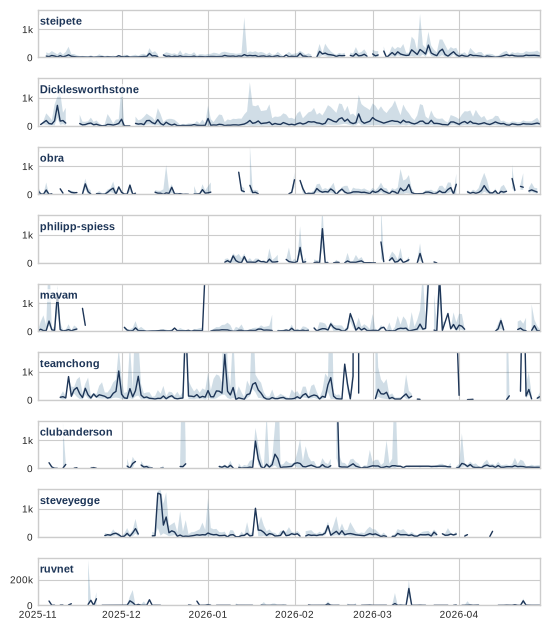

wrote /home/dig/repositories/what-are-they-doing/paper/figures/rq4/churn-evolution.pdf


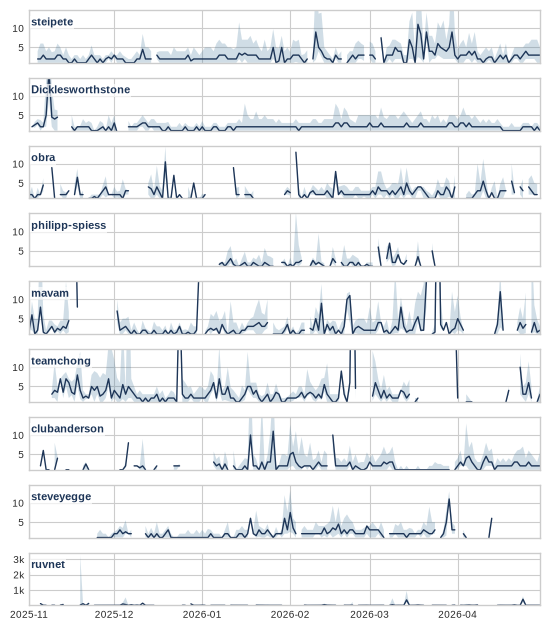

wrote /home/dig/repositories/what-are-they-doing/paper/figures/rq4/scattering-evolution.pdf


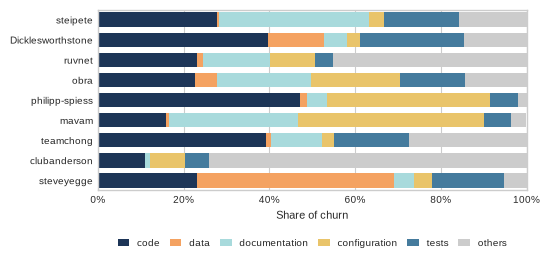

wrote /home/dig/repositories/what-are-they-doing/paper/figures/rq4/commit-categories.pdf


,commits,attributed_share,text_share,attributed_commits,attributed_median_churn,attributed_median_files,unattributed_commits,unattributed_median_churn,unattributed_median_files
developer,,,,,,,,,
Aggregate,"143,996",48.3%,47.1%,"69,533",98,2,"74,463",53,2
steipete,"35,089",2.8%,0.0%,981,63,3,"34,108",50,2
Dicklesworthstone,"70,843",75.0%,74.8%,"53,120",112,2,"17,723",45,1
ruvnet,"5,383",88.8%,87.5%,"4,782",40,1,601,243,3
obra,"4,419",49.4%,47.7%,"2,184",86,2,"2,235",75,2
philipp-spiess,808,4.1%,0.2%,33,64,2,775,27,2
mavam,"2,685",44.3%,36.3%,"1,190",34,2,"1,495",37,2
teamchong,"7,204",0.7%,0.5%,48,145,4,"7,156",81,2
clubanderson,"8,536",28.4%,27.5%,"2,428",52,2,"6,108",72,1


wrote /home/dig/repositories/what-are-they-doing/data/rq4/commit-distributions.csv, /home/dig/repositories/what-are-they-doing/data/rq4/commit-breadth.csv, /home/dig/repositories/what-are-they-doing/data/rq4/rework.csv, /home/dig/repositories/what-are-they-doing/data/rq4/attribution.csv, /home/dig/repositories/what-are-they-doing/data/rq4/commit-categories.csv, /home/dig/repositories/what-are-they-doing/data/rq4/monthly-medians.csv, /home/dig/repositories/what-are-they-doing/data/rq4/largest-others-files.csv, and LaTeX table fragments


In [26]:
from matplotlib.ticker import FuncFormatter

PAPER_FIGURE_SIZE = (5.6, 6.4)

def export_paper_figure(metric: str, filename: str, numeric_minimum: int = 0) -> None:
    """Write the paper version of a per-developer small-multiples figure.

    Developer names are drawn inside their panel so that the plotting area spans
    the full width of the page; the unit of the Y axis is given in the caption.
    The paper version shows the median and the interquartile band only, and the
    days that run above the shared range are left to the caption rather than
    annotated panel by panel.
    """
    daily_by_developer = {
        developer: daily_metric_summary(analysis, metric, developer)
        for developer in PANEL_ORDER
    }
    statistics = ["median", "p75"]

    def limit(frames: list[pd.DataFrame], coverage: float) -> float:
        plotted = pd.concat([frame[statistics].stack() for frame in frames])
        return float(plotted.quantile(coverage)) * 1.05

    shared_upper = limit(
        [daily_by_developer[developer] for developer in SHARED_DEVELOPERS], SHARED_COVERAGE
    )
    outlier_upper = limit([daily_by_developer[OUTLIER_DEVELOPER]], 1.0)

    fig, axes = plt.subplots(len(PANEL_ORDER), 1, figsize=PAPER_FIGURE_SIZE, sharex=True)
    for ax, developer in zip(axes, PANEL_ORDER):
        is_outlier = developer == OUTLIER_DEVELOPER
        daily = daily_by_developer[developer]
        upper = outlier_upper if is_outlier else shared_upper
        dates = daily.index.to_numpy()

        ax.fill_between(
            dates, daily["p25"].to_numpy(dtype=float), daily["p75"].to_numpy(dtype=float),
            color="#457b9d", alpha=0.25, linewidth=0,
        )
        ax.plot(dates, daily["median"], color="#1d3557", linewidth=1.0)
        ax.set_xlim(START_DATE, END_DATE)
        ax.set_ylim(numeric_minimum, upper)
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
        ax.yaxis.set_major_formatter(FuncFormatter(
            lambda value, _: f"{value:,.0f}" if value < 1000 else f"{value / 1000:,.0f}k"
        ))
        ax.tick_params(labelsize=7.5)
        ax.text(
            0.004, 0.86, developer, transform=ax.transAxes, ha="left", va="top",
            fontsize=8, fontweight="bold", color="#1d3557",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.0),
        )

    fig.tight_layout(rect=(0, 0, 1, 1))
    PAPER_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(PAPER_FIGURE_DIR / filename, bbox_inches="tight")
    plt.show()
    print(f"wrote {PAPER_FIGURE_DIR / filename}")

CATEGORY_FIGURE_SIZE = (5.6, 2.8)

def export_category_figure(filename: str = "commit-categories.pdf") -> None:
    """Write the paper version of the churn composition by developer.

    The exploratory version above carries its own title; here the figure is
    labeled by the caption, and the legend sits under the axis so that the bars
    span the full width of the column.
    """
    table = composition(file_touches, "developer", "churn").reindex(developer_order)

    fig, ax = plt.subplots(figsize=CATEGORY_FIGURE_SIZE)
    left = np.zeros(len(table))
    positions = np.arange(len(table))
    for category in CATEGORY_ORDER:
        values = table[category].to_numpy(dtype=float)
        ax.barh(positions, values, left=left, color=CATEGORY_COLORS[category],
                label=category, height=0.72)
        left += values
    ax.set_yticks(positions, table.index)
    ax.set_xlim(0, 1)
    ax.set_ylim(len(table) - 0.5, -0.5)
    ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    ax.tick_params(labelsize=7.5)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("Share of churn", fontsize=8)
    ax.legend(ncol=6, frameon=False, fontsize=7, loc="upper center",
              bbox_to_anchor=(0.5, -0.22), columnspacing=1.0, handlelength=1.2)

    fig.tight_layout()
    PAPER_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(PAPER_FIGURE_DIR / filename, bbox_inches="tight")
    plt.show()
    print(f"wrote {PAPER_FIGURE_DIR / filename}")

def latex_number(value: float, decimals: int = 0) -> str:
    return f"{value:,.{decimals}f}".replace(",", "\\,")

def latex_quantity(value: float) -> str:
    """Whole numbers stay whole; interpolated quantiles keep one decimal."""
    return latex_number(value, 0 if float(value).is_integer() else 1)

DISTRIBUTION_METRICS = [("churn", "Churn"), ("files_touched", "Files")]
DISTRIBUTION_POINTS = [0.05, 0.25, 0.50, 0.75, 0.95]

def distribution_frame() -> pd.DataFrame:
    """Per-commit distributions of churn and file scattering, cohort and per developer."""
    records = []
    groups = [("Aggregate", analysis)] + [
        (developer, analysis.loc[analysis["developer"] == developer]) for developer in developers
    ]
    for label, frame in groups:
        for metric, metric_label in DISTRIBUTION_METRICS:
            values = frame[metric]
            quantiles = values.quantile(DISTRIBUTION_POINTS)
            records.append({
                "developer": label, "metric": metric_label,
                "min": values.min(), "p5": quantiles.loc[0.05], "p25": quantiles.loc[0.25],
                "median": quantiles.loc[0.50], "mean": values.mean(),
                "p75": quantiles.loc[0.75], "p95": quantiles.loc[0.95], "max": values.max(),
            })
    return pd.DataFrame(records)

def latex_distribution_rows(distributions: pd.DataFrame) -> list[str]:
    columns = ["min", "p5", "p25", "median", "mean", "p75", "p95", "max"]
    lines = []
    for index, (label, rows) in enumerate(distributions.groupby("developer", sort=False)):
        if index:
            lines.append("    \\addlinespace")
        name = "\\textbf{Aggregate}" if label == "Aggregate" else label
        for _, row in rows.iterrows():
            cells = " & ".join(latex_quantity(row[column]) for column in columns)
            lines.append(f"    {name} & {row.metric} & {cells} \\\\")
    return lines

def attribution_frame() -> pd.DataFrame:
    """Attribution rate and per-commit size of each kind of commit, per developer."""
    records = []
    groups = [("Aggregate", analysis)] + [
        (developer, analysis.loc[analysis["developer"] == developer]) for developer in developers
    ]
    for label, frame in groups:
        attributed = frame.loc[frame["attribution"] == "agent-attributed"]
        unattributed = frame.loc[frame["attribution"] == "unattributed"]
        records.append({
            "developer": label,
            "commits": len(frame),
            "attributed_share": frame["agent_attributed"].mean(),
            "text_share": frame["text_attributed"].mean(),
            "attributed_commits": len(attributed),
            "attributed_median_churn": attributed["churn"].median(),
            "attributed_median_files": attributed["files_touched"].median(),
            "unattributed_commits": len(unattributed),
            "unattributed_median_churn": unattributed["churn"].median(),
            "unattributed_median_files": unattributed["files_touched"].median(),
        })
    return pd.DataFrame(records).set_index("developer")

def latex_attribution_rows(attribution: pd.DataFrame) -> list[str]:
    lines = []
    for developer, row in attribution.iterrows():
        name = "\\textbf{Aggregate}" if developer == "Aggregate" else developer
        lines.append(
            f"    {name} & {latex_number(row.commits)} & {row.attributed_share * 100:.1f} & "
            f"{row.text_share * 100:.1f} & {latex_number(row.attributed_commits)} & "
            f"{latex_quantity(row.attributed_median_churn)} & {latex_quantity(row.attributed_median_files)} & "
            f"{latex_number(row.unattributed_commits)} & {latex_quantity(row.unattributed_median_churn)} & "
            f"{latex_quantity(row.unattributed_median_files)} \\\\"
        )
    return lines

def latex_breadth_rows(breadth: pd.DataFrame) -> list[str]:
    lines = []
    for developer, row in breadth.iterrows():
        lines.append(
            f"    {developer} & {latex_number(row.commits)} & {latex_number(row.median_files)} & "
            f"{latex_number(row.p95_files)} & {latex_number(row.median_modules)} & "
            f"{latex_number(row.mean_modules, 2)} & {row.multi_module_share * 100:.1f} & "
            f"{row.focused_share * 100:.1f} & {row.scattered_share * 100:.1f} & "
            f"{latex_number(row.active_days)} & {latex_number(row.median_commits_per_day)} & "
            f"{latex_number(row.median_daily_churn)} \\\\"
        )
    return lines

def latex_revisit_rows(revisits: pd.DataFrame) -> list[str]:
    lines = []
    for developer, row in revisits.iterrows():
        lines.append(
            f"    {developer} & {latex_number(row.file_touches)} & "
            f"{latex_number(row.distinct_files)} & {row.touches_per_file:.2f} & "
            f"{row.revisit_share * 100:.1f} & {row.revisit_within_week * 100:.1f} & "
            f"{row.revisit_same_day * 100:.1f} \\\\"
        )
    return lines

def latex_tables(
    distributions: pd.DataFrame, breadth: pd.DataFrame, revisits: pd.DataFrame,
    attribution: pd.DataFrame,
) -> str:
    lines = ["% Generated by script/git-statistics/git-statistics.ipynb", "% Per-commit distributions"]
    lines.extend(latex_distribution_rows(distributions))
    lines.append("% Breadth and daily volume")
    for developer, row in breadth.iterrows():
        lines.append(
            f"    {developer} & {latex_number(row.commits)} & {latex_number(row.median_files)} & "
            f"{latex_number(row.p95_files)} & {latex_number(row.median_modules)} & "
            f"{latex_number(row.mean_modules, 2)} & {row.multi_module_share * 100:.1f} & "
            f"{row.focused_share * 100:.1f} & {row.scattered_share * 100:.1f} & "
            f"{latex_number(row.active_days)} & {latex_number(row.median_commits_per_day)} & "
            f"{latex_number(row.median_daily_churn)} \\\\"
        )
    lines.append("% File revisits")
    for developer, row in revisits.iterrows():
        lines.append(
            f"    {developer} & {latex_number(row.file_touches)} & "
            f"{latex_number(row.distinct_files)} & {row.touches_per_file:.2f} & "
            f"{row.revisit_share * 100:.1f} & {row.revisit_within_week * 100:.1f} & "
            f"{row.revisit_same_day * 100:.1f} \\\\"
        )
    lines.append("% Agent attribution")
    lines.extend(latex_attribution_rows(attribution))
    return "\n".join(lines) + "\n"

export_paper_figure("churn", "churn-evolution.pdf")
export_paper_figure("files_touched", "scattering-evolution.pdf", numeric_minimum=1)
export_category_figure()

distributions = distribution_frame()
display(distributions.set_index(["developer", "metric"]).style.format("{:,.1f}"))

attribution_summary = attribution_frame()
display(attribution_summary.style.format({
    "commits": "{:,.0f}", "attributed_share": "{:.1%}", "text_share": "{:.1%}",
    "attributed_commits": "{:,.0f}", "attributed_median_churn": "{:,.0f}",
    "attributed_median_files": "{:,.0f}", "unattributed_commits": "{:,.0f}",
    "unattributed_median_churn": "{:,.0f}", "unattributed_median_files": "{:,.0f}",
}))

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
distributions.to_csv(EXPORT_DIR / "commit-distributions.csv", index=False)
monthly_summary = pd.concat(
    [monthly_metric_summary(analysis, metric, developer).assign(developer=developer, metric=metric)
     for developer in developers for metric in ("churn", "files_touched")]
).reset_index()
monthly_summary.to_csv(EXPORT_DIR / "monthly-medians.csv", index=False)
attribution_summary.to_csv(EXPORT_DIR / "attribution.csv")
breadth.to_csv(EXPORT_DIR / "commit-breadth.csv")
revisits.to_csv(EXPORT_DIR / "rework.csv")
composition(file_touches, "developer", "churn").reindex(developer_order).to_csv(
    EXPORT_DIR / "commit-categories.csv"
)
largest_other_files.to_csv(EXPORT_DIR / "largest-others-files.csv", index=False)
def write_latex_fragment(path: Path, rows: list[str]) -> None:
    """Write rows for inclusion inside a tabular environment."""
    rows = rows.copy()
    rows[-1] = rows[-1].removesuffix(r" \\")
    path.write_text("\n".join(rows) + "\n")

write_latex_fragment(
    EXPORT_DIR / "commit-distributions.tex", latex_distribution_rows(distributions)
)
write_latex_fragment(EXPORT_DIR / "commit-breadth.tex", latex_breadth_rows(breadth))
write_latex_fragment(EXPORT_DIR / "rework.tex", latex_revisit_rows(revisits))
write_latex_fragment(
    EXPORT_DIR / "attribution.tex", latex_attribution_rows(attribution_summary)
)
(EXPORT_DIR / "tables.tex").write_text(
    latex_tables(distributions, breadth, revisits, attribution_summary)
)
print(f"wrote {EXPORT_DIR / 'commit-distributions.csv'}, {EXPORT_DIR / 'commit-breadth.csv'}, "
      f"{EXPORT_DIR / 'rework.csv'}, {EXPORT_DIR / 'attribution.csv'}, "
      f"{EXPORT_DIR / 'commit-categories.csv'}, {EXPORT_DIR / 'monthly-medians.csv'}, "
      f"{EXPORT_DIR / 'largest-others-files.csv'}, and LaTeX table fragments")

## Main outlier commits

Percentile curves compress the upper tail and can be difficult to interpret for these highly skewed distributions. The tables below instead identify the concrete commits driving the extremes. They show the ten largest commits across the cohort and the five largest for every developer, ranked separately by additions, deletions, gross churn, and files touched. Each row links to the commit on GitHub.

A cached value of 300 files should be treated as a possible lower bound because the collector retained only the first REST response. GitHub pagination supports up to 3,000 files, while the independent Git calculation below has no corresponding API-page ceiling.

In [27]:
OUTLIER_COLUMNS = [
    "developer", "day", "repository", "sha",
    "additions", "deletions", "churn", "files_touched", "commit_url",
]

def ranked_outliers(frame: pd.DataFrame, metric: str, count: int) -> pd.DataFrame:
    ranked = frame.copy()
    ranked["commit_url"] = ranked.apply(
        lambda row: (
            f"https://github.com/{row['repository']}/commit/{row['sha']}"
            if pd.notna(row["repository"]) else None
        ),
        axis=1,
    )
    ranked = ranked.sort_values(
        [metric, "churn", "files_touched", "day", "sha"],
        ascending=[False, False, False, True, True],
    ).head(count)
    return ranked[OUTLIER_COLUMNS].reset_index(drop=True)

def display_outliers(table: pd.DataFrame) -> None:
    display(table.style.format(
        {
            "day": lambda value: value.strftime("%Y-%m-%d"),
            "additions": "{:,.0f}",
            "deletions": "{:,.0f}",
            "churn": "{:,.0f}",
            "files_touched": "{:,.0f}",
        },
        hyperlinks="html",
    ))

OUTLIER_CATEGORIES = [
    ("additions", "Commits adding the most lines"),
    ("deletions", "Commits deleting the most lines"),
    ("churn", "Largest commits by gross churn"),
    ("files_touched", "Commits touching the most files"),
]

for metric, label in OUTLIER_CATEGORIES:
    print(f"{label} — all developers")
    display_outliers(ranked_outliers(analysis, metric, 10))

    print(f"{label} — top five per developer")
    per_developer = pd.concat(
        [ranked_outliers(analysis.loc[analysis["developer"] == developer], metric, 5) for developer in developers],
        ignore_index=True,
    )
    display_outliers(per_developer)

assert analysis["churn"].ge(0).all() and analysis["files_touched"].ge(0).all()
assert per_developer["commit_url"].str.startswith("https://github.com/").all()

Commits adding the most lines — all developers


,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,Dicklesworthstone,2026-01-14,Dicklesworthstone/beads_viewer,fdd2f75f2dbeeb1c48e73f509ee6273a409b1f1f,"6,855,492",0,"6,855,492","3,304",https://github.com/Dicklesworthstone/beads_viewer/commit/fdd2f75f2dbeeb1c48e73f509ee6273a409b1f1f
1,clubanderson,2026-02-24,kubestellar/copilot-remote,d96f25f324ec40646ca9463cc9710f9b3d71b6d6,"3,925,715",0,"3,925,715","19,664",https://github.com/kubestellar/copilot-remote/commit/d96f25f324ec40646ca9463cc9710f9b3d71b6d6
2,ruvnet,2026-03-01,ruvnet/RuView,dd419daa81b4e6bbc06b82856d852ce8dca06f0a,"3,526,891","3,830","3,530,721","7,890",https://github.com/ruvnet/RuView/commit/dd419daa81b4e6bbc06b82856d852ce8dca06f0a
3,ruvnet,2026-02-28,ruvnet/wifi-densepose,cd5943df2346337b5f1b0433b3671b6c582c4e62,"3,522,914",0,"3,522,914","7,854",https://github.com/ruvnet/wifi-densepose/commit/cd5943df2346337b5f1b0433b3671b6c582c4e62
4,ruvnet,2026-02-28,ruvnet/wifi-densepose,d803bfe2b1fe7f5e219e50ac20d6801a0a58ac75,"3,522,914",0,"3,522,914","7,854",https://github.com/ruvnet/wifi-densepose/commit/d803bfe2b1fe7f5e219e50ac20d6801a0a58ac75
5,Dicklesworthstone,2026-02-05,Dicklesworthstone/pi_agent_rust,788be98464140c64a3d56b664e28e8b2875c3177,"2,936,188",0,"2,936,188","17,647",https://github.com/Dicklesworthstone/pi_agent_rust/commit/788be98464140c64a3d56b664e28e8b2875c3177
6,steipete,2026-04-28,openclaw/clawsweeper,4b372f81abb56319835f50e3e361d46139d4c8b6,"2,348,356",213,"2,348,569","19,839",https://github.com/openclaw/clawsweeper/commit/4b372f81abb56319835f50e3e361d46139d4c8b6
7,Dicklesworthstone,2026-04-03,Dicklesworthstone/frankenmermaid,032b1ffd4b440a8677a86ed0af2df1362e8b8a18,"2,126,079",39,"2,126,118",365,https://github.com/Dicklesworthstone/frankenmermaid/commit/032b1ffd4b440a8677a86ed0af2df1362e8b8a18
8,Dicklesworthstone,2026-03-21,Dicklesworthstone/asupersync,b3835ddd95eb823ba6a108cc07df4f367adb8b66,"2,103,306",0,"2,103,306",461,https://github.com/Dicklesworthstone/asupersync/commit/b3835ddd95eb823ba6a108cc07df4f367adb8b66
9,ruvnet,2026-03-03,ruvnet/RuView,407b46b206757e6c2e7c71cbac3e3f1e7b88b843,"1,852,646",0,"1,852,646","1,600",https://github.com/ruvnet/RuView/commit/407b46b206757e6c2e7c71cbac3e3f1e7b88b843


Commits adding the most lines — top five per developer


,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,steipete,2026-04-28,openclaw/clawsweeper,4b372f81abb56319835f50e3e361d46139d4c8b6,"2,348,356",213,"2,348,569","19,839",https://github.com/openclaw/clawsweeper/commit/4b372f81abb56319835f50e3e361d46139d4c8b6
1,steipete,2025-12-06,openclaw/openclaw,c5c50a2141f2cdd805ae9b70a14a2e66dabac9b6,"561,060",101,"561,161","3,423",https://github.com/openclaw/openclaw/commit/c5c50a2141f2cdd805ae9b70a14a2e66dabac9b6
2,steipete,2026-04-05,openclaw/docs,aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d,"360,417",4,"360,421","1,608",https://github.com/openclaw/docs/commit/aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d
3,steipete,2025-12-17,openclaw/openclaw,875cf9a0543d303d503ee834c08878a64cab55e8,"218,063","776,607","994,670","7,451",https://github.com/openclaw/openclaw/commit/875cf9a0543d303d503ee834c08878a64cab55e8
4,steipete,2026-04-29,openclaw/clawsweeper,54ead181ad1ef70233ac266211827492e6928e64,"196,605",106,"196,711","1,502",https://github.com/openclaw/clawsweeper/commit/54ead181ad1ef70233ac266211827492e6928e64
5,Dicklesworthstone,2026-01-14,Dicklesworthstone/beads_viewer,fdd2f75f2dbeeb1c48e73f509ee6273a409b1f1f,"6,855,492",0,"6,855,492","3,304",https://github.com/Dicklesworthstone/beads_viewer/commit/fdd2f75f2dbeeb1c48e73f509ee6273a409b1f1f
6,Dicklesworthstone,2026-02-05,Dicklesworthstone/pi_agent_rust,788be98464140c64a3d56b664e28e8b2875c3177,"2,936,188",0,"2,936,188","17,647",https://github.com/Dicklesworthstone/pi_agent_rust/commit/788be98464140c64a3d56b664e28e8b2875c3177
7,Dicklesworthstone,2026-04-03,Dicklesworthstone/frankenmermaid,032b1ffd4b440a8677a86ed0af2df1362e8b8a18,"2,126,079",39,"2,126,118",365,https://github.com/Dicklesworthstone/frankenmermaid/commit/032b1ffd4b440a8677a86ed0af2df1362e8b8a18
8,Dicklesworthstone,2026-03-21,Dicklesworthstone/asupersync,b3835ddd95eb823ba6a108cc07df4f367adb8b66,"2,103,306",0,"2,103,306",461,https://github.com/Dicklesworthstone/asupersync/commit/b3835ddd95eb823ba6a108cc07df4f367adb8b66
9,Dicklesworthstone,2026-02-15,Dicklesworthstone/frankenlibc,fc9fcae7ad386fcb40af1867a6e0ae569a650907,"1,700,861",8,"1,700,869",7,https://github.com/Dicklesworthstone/frankenlibc/commit/fc9fcae7ad386fcb40af1867a6e0ae569a650907


Commits deleting the most lines — all developers


...

,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,steipete,2026-04-28,openclaw/clawsweeper,b10027889cdc3ac0ac3ac00f2ccedbe3d4611f85,"17,920","2,364,214","2,382,134","20,241",https://github.com/openclaw/clawsweeper/commit/b10027889cdc3ac0ac3ac00f2ccedbe3d4611f85
1,steipete,2026-04-28,openclaw/clawsweeper,4b372f81abb56319835f50e3e361d46139d4c8b6,"2,348,356",213,"2,348,569","19,839",https://github.com/openclaw/clawsweeper/commit/4b372f81abb56319835f50e3e361d46139d4c8b6
2,steipete,2025-12-17,openclaw/openclaw,875cf9a0543d303d503ee834c08878a64cab55e8,"218,063","776,607","994,670","7,451",https://github.com/openclaw/openclaw/commit/875cf9a0543d303d503ee834c08878a64cab55e8
3,steipete,2025-12-06,openclaw/openclaw,c5c50a2141f2cdd805ae9b70a14a2e66dabac9b6,"561,060",101,"561,161","3,423",https://github.com/openclaw/openclaw/commit/c5c50a2141f2cdd805ae9b70a14a2e66dabac9b6
4,steipete,2026-04-05,openclaw/docs,aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d,"360,417",4,"360,421","1,608",https://github.com/openclaw/docs/commit/aaca615b6b1bd3b0844dbe4ddf3fe71b0adc2c0d
5,Dicklesworthstone,2026-01-14,Dicklesworthstone/beads_viewer,fdd2f75f2dbeeb1c48e73f509ee6273a409b1f1f,"6,855,492",0,"6,855,492","3,304",https://github.com/Dicklesworthstone/beads_viewer/commit/fdd2f75f2dbeeb1c48e73f509ee6273a409b1f1f
6,Dicklesworthstone,2026-02-05,Dicklesworthstone/pi_agent_rust,788be98464140c64a3d56b664e28e8b2875c3177,"2,936,188",0,"2,936,188","17,647",https://github.com/Dicklesworthstone/pi_agent_rust/commit/788be98464140c64a3d56b664e28e8b2875c3177
7,Dicklesworthstone,2026-04-03,Dicklesworthstone/frankenmermaid,032b1ffd4b440a8677a86ed0af2df1362e8b8a18,"2,126,079",39,"2,126,118",365,https://github.com/Dicklesworthstone/frankenmermaid/commit/032b1ffd4b440a8677a86ed0af2df1362e8b8a18
8,Dicklesworthstone,2026-03-21,Dicklesworthstone/asupersync,b3835ddd95eb823ba6a108cc07df4f367adb8b66,"2,103,306",0,"2,103,306",461,https://github.com/Dicklesworthstone/asupersync/commit/b3835ddd95eb823ba6a108cc07df4f367adb8b66
9,Dicklesworthstone,2026-02-15,Dicklesworthstone/frankenlibc,fc9fcae7ad386fcb40af1867a6e0ae569a650907,"1,700,861",8,"1,700,869",7,https://github.com/Dicklesworthstone/frankenlibc/commit/fc9fcae7ad386fcb40af1867a6e0ae569a650907


Commits touching the most files — all developers


,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,steipete,2026-04-28,openclaw/clawsweeper,b10027889cdc3ac0ac3ac00f2ccedbe3d4611f85,"17,920","2,364,214","2,382,134","20,241",https://github.com/openclaw/clawsweeper/commit/b10027889cdc3ac0ac3ac00f2ccedbe3d4611f85
1,steipete,2026-04-28,openclaw/clawsweeper,4b372f81abb56319835f50e3e361d46139d4c8b6,"2,348,356",213,"2,348,569","19,839",https://github.com/openclaw/clawsweeper/commit/4b372f81abb56319835f50e3e361d46139d4c8b6
2,clubanderson,2026-02-24,kubestellar/copilot-remote,d96f25f324ec40646ca9463cc9710f9b3d71b6d6,"3,925,715",0,"3,925,715","19,664",https://github.com/kubestellar/copilot-remote/commit/d96f25f324ec40646ca9463cc9710f9b3d71b6d6
3,clubanderson,2026-02-24,kubestellar/copilot-remote,e2d053c5af80f34a947264be044d2f9c34754452,5,"3,914,668","3,914,673","19,639",https://github.com/kubestellar/copilot-remote/commit/e2d053c5af80f34a947264be044d2f9c34754452
4,Dicklesworthstone,2026-02-05,Dicklesworthstone/pi_agent_rust,788be98464140c64a3d56b664e28e8b2875c3177,"2,936,188",0,"2,936,188","17,647",https://github.com/Dicklesworthstone/pi_agent_rust/commit/788be98464140c64a3d56b664e28e8b2875c3177
5,ruvnet,2026-01-15,ruvnet/ruflo,dd7a5ec81d7d0fe0361e56abf89c5ac2b00f4ccc,"682,334","339,562","1,021,896","9,675",https://github.com/ruvnet/ruflo/commit/dd7a5ec81d7d0fe0361e56abf89c5ac2b00f4ccc
6,ruvnet,2026-03-04,ruvnet/RuView,6e76578dcf0dbbed26cc1ef8569d993eedd44585,12,"5,418,272","5,418,284","9,612",https://github.com/ruvnet/RuView/commit/6e76578dcf0dbbed26cc1ef8569d993eedd44585
7,ruvnet,2026-03-04,ruvnet/RuView,c6f061a191d6b9e2a5eec05dad9c6c74067bdf11,12,"5,418,272","5,418,284","9,612",https://github.com/ruvnet/RuView/commit/c6f061a191d6b9e2a5eec05dad9c6c74067bdf11
8,ruvnet,2026-01-04,ruvnet/ruflo,80a7f9f4fc5a8504468e2a50ef2b6a812651387f,"54,153","100,193","154,346","7,980",https://github.com/ruvnet/ruflo/commit/80a7f9f4fc5a8504468e2a50ef2b6a812651387f
9,ruvnet,2026-03-01,ruvnet/RuView,dd419daa81b4e6bbc06b82856d852ce8dca06f0a,"3,526,891","3,830","3,530,721","7,890",https://github.com/ruvnet/RuView/commit/dd419daa81b4e6bbc06b82856d852ce8dca06f0a


Commits touching the most files — top five per developer


,developer,day,repository,sha,additions,deletions,churn,files_touched,commit_url
0,steipete,2026-04-28,openclaw/clawsweeper,b10027889cdc3ac0ac3ac00f2ccedbe3d4611f85,"17,920","2,364,214","2,382,134","20,241",https://github.com/openclaw/clawsweeper/commit/b10027889cdc3ac0ac3ac00f2ccedbe3d4611f85
1,steipete,2026-04-28,openclaw/clawsweeper,4b372f81abb56319835f50e3e361d46139d4c8b6,"2,348,356",213,"2,348,569","19,839",https://github.com/openclaw/clawsweeper/commit/4b372f81abb56319835f50e3e361d46139d4c8b6
2,steipete,2025-12-17,openclaw/openclaw,875cf9a0543d303d503ee834c08878a64cab55e8,"218,063","776,607","994,670","7,451",https://github.com/openclaw/openclaw/commit/875cf9a0543d303d503ee834c08878a64cab55e8
3,steipete,2025-12-17,openclaw/openclaw,3ed33c5856bd2d2a4e009fef96885e4722b8449a,0,"218,323","218,323","3,669",https://github.com/openclaw/openclaw/commit/3ed33c5856bd2d2a4e009fef96885e4722b8449a
4,steipete,2025-12-06,openclaw/openclaw,c5c50a2141f2cdd805ae9b70a14a2e66dabac9b6,"561,060",101,"561,161","3,423",https://github.com/openclaw/openclaw/commit/c5c50a2141f2cdd805ae9b70a14a2e66dabac9b6
5,Dicklesworthstone,2026-02-05,Dicklesworthstone/pi_agent_rust,788be98464140c64a3d56b664e28e8b2875c3177,"2,936,188",0,"2,936,188","17,647",https://github.com/Dicklesworthstone/pi_agent_rust/commit/788be98464140c64a3d56b664e28e8b2875c3177
6,Dicklesworthstone,2026-01-21,Dicklesworthstone/coding_agent_session_search,6526759f2cf4c45ca50d1adbf0ed24d9729446b1,"58,972",77,"59,049","6,270",https://github.com/Dicklesworthstone/coding_agent_session_search/commit/6526759f2cf4c45ca50d1adbf0ed24d9729446b1
7,Dicklesworthstone,2026-01-17,Dicklesworthstone/flywheel_connectors,1539c3b21292b396484c9e557bcc541ebe531a8b,"55,564",0,"55,564","5,823",https://github.com/Dicklesworthstone/flywheel_connectors/commit/1539c3b21292b396484c9e557bcc541ebe531a8b
8,Dicklesworthstone,2026-02-04,Dicklesworthstone/flywheel_connectors,e80dbbc5b0927e61f2168e9996ba5d30df205805,0,"55,516","55,516","5,821",https://github.com/Dicklesworthstone/flywheel_connectors/commit/e80dbbc5b0927e61f2168e9996ba5d30df205805
9,Dicklesworthstone,2026-04-20,Dicklesworthstone/flywheel_connectors,a14273cd4d0c63eb2ec3cef4c7f8bf7a7e40e178,"8,527",46,"8,573","5,170",https://github.com/Dicklesworthstone/flywheel_connectors/commit/a14273cd4d0c63eb2ec3cef4c7f8bf7a7e40e178
